In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import detrend
import scipy.stats as stats
from scipy.stats import bootstrap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import geopandas as gpd
import seaborn as sns
from math import radians, cos
import rasterio
from matplotlib.colors import LinearSegmentedColormap
from rasterio.transform import from_origin
import xskillscore as xs
import shapely.geometry
from shapely.geometry import box
from shapely.ops import unary_union
import matplotlib.patches as mpatches
import pickle
import os
import regionmask

In [2]:
file_path = '/home/madhulika.gurazada/paper2/Data/Nino3.4_OG_SST1.xlsx'

nino34 = pd.read_excel(file_path)

nino34_1900_2024 = nino34[(nino34['Year'] >= 1900) & (nino34['Year'] <= 2024)]

def select_seasons(data):
    # Create DJF (December, January, February) within the function
    djf_data = pd.DataFrame(columns=['Year', 'Dec', 'Jan', 'Feb'])
    djf_data['Year'] = data['Year'] 
    djf_data['Dec'] = data['Dec']
    djf_data['Jan'] = data['Jan'].shift(-1)
    djf_data['Feb'] = data['Feb'].shift(-1)
    
    return djf_data

# Assuming you have already read the data into 'nino34_1900_2022'
djf_data = select_seasons(nino34_1900_2024)

# Define the columns for each season
seasonal_columns = {
    'DJF': ['Dec', 'Jan', 'Feb']
}

# Create a dictionary to hold the DataFrames
seasonal_data = {
    'DJF': djf_data
}

climatology_start_year = 1991
climatology_end_year = 2020

# Calculate seasonal means for each DataFrame
for season, columns in seasonal_columns.items():
    data = seasonal_data[season]
    data[f'{season}_Mean'] = data[columns].mean(axis=1)
    # Filter the data for the climatology years
    climatology_data = data[(data['Year'] >= climatology_start_year) & (data['Year'] <= climatology_end_year)]
    climatology_mean = climatology_data[f'{season}_Mean'].mean()
    climatology_std = climatology_data[f'{season}_Mean'].std()
    # Calculate Nino anomalies
    data[f'Nino_{season}_Anomaly'] = (data[f'{season}_Mean'] - climatology_mean)/climatology_std
    # Classify as El Niño, La Niña, or Neutral
    data[f'Nino_{season}_Classification'] = np.where(data[f'Nino_{season}_Anomaly'] > 0.5, 'El Niño',
                                                     np.where(data[f'Nino_{season}_Anomaly'] < -0.5, 'La Niña', 'Neutral'))
    
el_nino_years = {}
la_nina_years = {}
neutral_years = {}

for season in seasonal_columns.keys():
    data = seasonal_data[season]
    # Extract the years for each classification and filter for years between 1901 and 2024
    el_nino_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'El Niño')]['Year'].tolist()
    la_nina_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'La Niña')]['Year'].tolist()
    neutral_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'Neutral')]['Year'].tolist()

el_nino_years_1 = [year + 1 for year in el_nino_years['DJF']]
la_nina_years_1 = [year + 1 for year in la_nina_years['DJF']]
neutral_years_1 = [year + 1 for year in neutral_years['DJF']]

In [3]:
print(el_nino_years)
print(la_nina_years)
print(neutral_years)

{'DJF': [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]}
{'DJF': [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]}
{'DJF': [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]}


In [4]:
cru_pre = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.pre.dat.nc')
cru_pre.info()  

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
pre_mam_data = cru_pre.sel(time=cru_pre['time.month'].isin(mam_months))
pre_jja_data = cru_pre.sel(time=cru_pre['time.month'].isin(jja_months))
pre_son_data = cru_pre.sel(time=cru_pre['time.month'].isin(son_months))

pre_mam_data['year'] = pre_mam_data['time'].dt.year
pre_mam1_data_year = pre_mam_data['year'] + 1
pre_mam1_data_year = pre_mam1_data_year[pre_mam1_data_year != 2025]
pre_mam1_data = pre_mam_data.sel(time=pre_mam_data['time.year'].isin(pre_mam1_data_year))

pre_jja_data['year'] = pre_jja_data['time'].dt.year
pre_jja1_data_year = pre_jja_data['year'] + 1
pre_jja1_data_year = pre_jja1_data_year[pre_jja1_data_year != 2025]
pre_jja1_data = pre_jja_data.sel(time=pre_jja_data['time.year'].isin(pre_jja1_data_year))

pre_son_data['year'] = pre_son_data['time'].dt.year
pre_son1_data_year = pre_son_data['year'] + 1
pre_son1_data_year = pre_son1_data_year[pre_son1_data_year != 2025]
pre_son1_data = pre_son_data.sel(time=pre_son_data['time.year'].isin(pre_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_pre.sel(time=(cru_pre['time.month'] == 12) & (cru_pre['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_pre.sel(time=(cru_pre['time.month'] == 1) & (cru_pre['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_pre.sel(time=(cru_pre['time.month'] == 2) & (cru_pre['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
pre_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
# pre_mam_mean_yearly = calculate_yearly_mean(pre_mam_data)
pre_jja_mean_yearly = calculate_yearly_mean(pre_jja_data)
pre_son_mean_yearly = calculate_yearly_mean(pre_son_data)
pre_djf_mean_yearly = calculate_yearly_mean(pre_djf_data)
pre_mam1_mean_yearly = calculate_yearly_mean(pre_mam1_data)
pre_jja1_mean_yearly = calculate_yearly_mean(pre_jja1_data)
pre_son1_mean_yearly = calculate_yearly_mean(pre_son1_data)

def plot_precipitation_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    pre_median = dataset['pre'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, pre_median, marker='o', linestyle='-')
    plt.title(f'Precipitation ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    pre_median = dataarray['pre'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_pre_median = detrend(pre_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_pre_median_da = xr.DataArray(
        detrended_pre_median, 
        dims=['year'], 
        coords={'year': pre_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(pre_median['year'], detrended_pre_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Precipitation')
    plt.title(f'Detrended Median Yearly Precipitation ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
# pre_el_nino_composite_mam = pre_mam_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_jja = pre_jja_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_son = pre_son_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_djf = pre_djf_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_mam1 = pre_mam1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_jja1 = pre_jja1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_son1 = pre_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
# pre_mam_el_nino = pre_el_nino_composite_mam.mean(dim='year')['pre']
pre_jja_el_nino = pre_el_nino_composite_jja.mean(dim='year')['pre']
pre_son_el_nino = pre_el_nino_composite_son.mean(dim='year')['pre']
pre_djf_el_nino = pre_el_nino_composite_djf.mean(dim='year')['pre']
pre_mam1_el_nino = pre_el_nino_composite_mam1.mean(dim='year')['pre']
pre_jja1_el_nino = pre_el_nino_composite_jja1.mean(dim='year')['pre']
pre_son1_el_nino = pre_el_nino_composite_son1.mean(dim='year')['pre']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

# pre_la_nina_composite_mam = pre_mam_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_jja = pre_jja_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_son = pre_son_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_djf = pre_djf_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_mam1 = pre_mam1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_jja1 = pre_jja1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_son1 = pre_son1_mean_yearly.sel(year=la_nina_years_1)

# pre_mam_la_nina = pre_la_nina_composite_mam.mean(dim='year')['pre']
pre_jja_la_nina = pre_la_nina_composite_jja.mean(dim='year')['pre']
pre_son_la_nina = pre_la_nina_composite_son.mean(dim='year')['pre']
pre_djf_la_nina = pre_la_nina_composite_djf.mean(dim='year')['pre']
pre_mam1_la_nina = pre_la_nina_composite_mam1.mean(dim='year')['pre']
pre_jja1_la_nina = pre_la_nina_composite_jja1.mean(dim='year')['pre']
pre_son1_la_nina = pre_la_nina_composite_son1.mean(dim='year')['pre']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]
neutral_years_1 = neutral_years_1[:-1]

# pre_neutral_composite_mam = pre_mam_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_jja = pre_jja_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_son = pre_son_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_djf = pre_djf_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_mam1 = pre_mam1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_jja1 = pre_jja1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_son1 = pre_son1_mean_yearly.sel(year=neutral_years_1)

# pre_mam_neutral = pre_neutral_composite_mam.mean(dim='year')['pre']
pre_jja_neutral = pre_neutral_composite_jja.mean(dim='year')['pre']
pre_son_neutral = pre_neutral_composite_son.mean(dim='year')['pre']
pre_djf_neutral = pre_neutral_composite_djf.mean(dim='year')['pre']
pre_mam1_neutral = pre_neutral_composite_mam1.mean(dim='year')['pre']
pre_jja1_neutral = pre_neutral_composite_jja1.mean(dim='year')['pre']
pre_son1_neutral = pre_neutral_composite_son1.mean(dim='year')['pre']

pre_el_nino_differences = [pre_jja_el_nino - pre_jja_neutral, pre_son_el_nino - pre_son_neutral, pre_djf_el_nino - pre_djf_neutral, pre_mam1_el_nino - pre_mam1_neutral, pre_jja1_el_nino - pre_jja1_neutral, pre_son1_el_nino - pre_son1_neutral]
pre_la_nina_differences = [pre_jja_la_nina - pre_jja_neutral, pre_son_la_nina - pre_son_neutral, pre_djf_la_nina - pre_djf_neutral, pre_mam1_la_nina - pre_mam1_neutral, pre_jja1_la_nina - pre_jja1_neutral, pre_son1_la_nina - pre_son1_neutral]

# Get the dimensions of the dataset
lat_size = pre_jja_mean_yearly.dims['lat']
lon_size = pre_jja_mean_yearly.dims['lon']
year_size = pre_jja_mean_yearly.sizes['year']
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': pre_jja_mean_yearly['year'], 'lat': pre_jja_mean_yearly['lat'], 
                                           'lon': pre_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = pre_jja_mean_yearly['pre'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['pre'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

datasets = {'pre_jja_mean_yearly': pre_jja_mean_yearly,
            'pre_son_mean_yearly': pre_son_mean_yearly,
            'pre_djf_mean_yearly': pre_djf_mean_yearly,
            'pre_mam1_mean_yearly': pre_mam1_mean_yearly,
            'pre_jja1_mean_yearly': pre_jja1_mean_yearly,
            'pre_son1_mean_yearly': pre_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='BrBG', transform=ccrs.PlateCarree(), vmin=-20, vmax=20)

    # Add colorbar
    plt.colorbar(label='Detrended Precipitation')

    # Add title and labels
    plt.title(f'Detrended Precipitation for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()
    
# List of the datasets
pre_datasets = [detrended_datasets_xr['pre_jja_mean_yearly'], detrended_datasets_xr['pre_son_mean_yearly'], detrended_datasets_xr['pre_djf_mean_yearly'], detrended_datasets_xr['pre_mam1_mean_yearly'], detrended_datasets_xr['pre_jja1_mean_yearly'], detrended_datasets_xr['pre_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
pre_datasets_climatology = []

# Loop through each dataset and select the climatology period
for pre_dataset in pre_datasets:
    pre_dataset_climatology = pre_dataset.sel(year=climatology_period)
    pre_datasets_climatology.append(pre_dataset_climatology)
    
# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for pre_dataset_climatology in pre_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = pre_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = pre_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)

standardized_anomalies = []

for pre_dataset, mean, std_dev in zip(pre_datasets, means, std_devs):
    standardized_anomaly = (pre_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_pre_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

if len(la_nina_years_djf) > 0:
    la_nina_years_djf.pop()

for i in range(6):
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_pre_anom_el = el_nino_std_anom
std_pre_anom_la = la_nina_std_anom
std_pre_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 pre(time, lat, lon) ;
		pre:long_name = precipitation ;
		pre:units = mm/month ;
		pre:correlation_decay_distance = 450.0 ;
	float64 stn(time, lat, lon) ;
		stn:description = number of stations contributing to each datum ;
	float32 mae(time, lat, lon) ;
		mae:description = mean of absolute diffs between interpolant anomalies and interpolated anomaly, where available ;
	float32 maea(time, lat, lon) ;
		maea:description = MAE anomaly, relative to long-term mean ;

// global attributes:
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Precipitation ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:pre.2503051121.dtb ;

In [5]:
cru_tmx = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.tmx.dat.nc')
cru_tmx.info()

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
tmx_mam_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(mam_months))
tmx_jja_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(jja_months))
tmx_son_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(son_months))

tmx_mam_data['year'] = tmx_mam_data['time'].dt.year
tmx_mam1_data_year = tmx_mam_data['year'] + 1
tmx_mam1_data_year = tmx_mam1_data_year[tmx_mam1_data_year != 2025]
tmx_mam1_data = tmx_mam_data.sel(time=tmx_mam_data['time.year'].isin(tmx_mam1_data_year))

tmx_jja_data['year'] = tmx_jja_data['time'].dt.year
tmx_jja1_data_year = tmx_jja_data['year'] + 1
tmx_jja1_data_year = tmx_jja1_data_year[tmx_jja1_data_year != 2025]
tmx_jja1_data = tmx_jja_data.sel(time=tmx_jja_data['time.year'].isin(tmx_jja1_data_year))

tmx_son_data['year'] = tmx_son_data['time'].dt.year
tmx_son1_data_year = tmx_son_data['year'] + 1
tmx_son1_data_year = tmx_son1_data_year[tmx_son1_data_year != 2025]
tmx_son1_data = tmx_son_data.sel(time=tmx_son_data['time.year'].isin(tmx_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_tmx.sel(time=(cru_tmx['time.month'] == 12) & (cru_tmx['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_tmx.sel(time=(cru_tmx['time.month'] == 1) & (cru_tmx['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_tmx.sel(time=(cru_tmx['time.month'] == 2) & (cru_tmx['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
tmx_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
tmx_jja_mean_yearly = calculate_yearly_mean(tmx_jja_data)
tmx_son_mean_yearly = calculate_yearly_mean(tmx_son_data)
tmx_djf_mean_yearly = calculate_yearly_mean(tmx_djf_data)
tmx_mam1_mean_yearly = calculate_yearly_mean(tmx_mam1_data)
tmx_jja1_mean_yearly = calculate_yearly_mean(tmx_jja1_data)
tmx_son1_mean_yearly = calculate_yearly_mean(tmx_son1_data)

def plot_temperature_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    tmx_median = dataset['tmx'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, tmx_median, marker='o', linestyle='-')
    plt.title(f'Temperature ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Tmax (degC)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    tmx_median = dataarray['tmx'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_tmx_median = detrend(tmx_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_tmx_median_da = xr.DataArray(
        detrended_tmx_median, 
        dims=['year'], 
        coords={'year': tmx_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(tmx_median['year'], detrended_tmx_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Max Temperature')
    plt.title(f'Detrended Median Yearly Max Temperature ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
el_nino_composite_jja = tmx_jja_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_son = tmx_son_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_djf = tmx_djf_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_mam1 = tmx_mam1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_jja1 = tmx_jja1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_son1 = tmx_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
tmx_jja_el_nino = el_nino_composite_jja.mean(dim='year')['tmx']
tmx_son_el_nino = el_nino_composite_son.mean(dim='year')['tmx']
tmx_djf_el_nino = el_nino_composite_djf.mean(dim='year')['tmx']
tmx_mam1_el_nino = el_nino_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_el_nino = el_nino_composite_jja1.mean(dim='year')['tmx']
tmx_son1_el_nino = el_nino_composite_son1.mean(dim='year')['tmx']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

la_nina_composite_jja = tmx_jja_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_son = tmx_son_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_djf = tmx_djf_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_mam1 = tmx_mam1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_jja1 = tmx_jja1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_son1 = tmx_son1_mean_yearly.sel(year=la_nina_years_1)

tmx_jja_la_nina = la_nina_composite_jja.mean(dim='year')['tmx']
tmx_son_la_nina = la_nina_composite_son.mean(dim='year')['tmx']
tmx_djf_la_nina = la_nina_composite_djf.mean(dim='year')['tmx']
tmx_mam1_la_nina = la_nina_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_la_nina = la_nina_composite_jja1.mean(dim='year')['tmx']
tmx_son1_la_nina = la_nina_composite_son1.mean(dim='year')['tmx']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]

neutral_composite_jja = tmx_jja_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_son = tmx_son_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_djf = tmx_djf_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_mam1 = tmx_mam1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_jja1 = tmx_jja1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_son1 = tmx_son1_mean_yearly.sel(year=neutral_years_1)

tmx_jja_neutral = neutral_composite_jja.mean(dim='year')['tmx']
tmx_son_neutral = neutral_composite_son.mean(dim='year')['tmx']
tmx_djf_neutral = neutral_composite_djf.mean(dim='year')['tmx']
tmx_mam1_neutral = neutral_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_neutral = neutral_composite_jja1.mean(dim='year')['tmx']
tmx_son1_neutral = neutral_composite_son1.mean(dim='year')['tmx']

tmx_el_nino_differences = [tmx_jja_el_nino - tmx_jja_neutral, tmx_son_el_nino - tmx_son_neutral, tmx_djf_el_nino - tmx_djf_neutral, tmx_mam1_el_nino - tmx_mam1_neutral, tmx_jja1_el_nino - tmx_jja1_neutral, tmx_son1_el_nino - tmx_son1_neutral]
tmx_la_nina_differences = [tmx_jja_la_nina - tmx_jja_neutral, tmx_son_la_nina - tmx_son_neutral, tmx_djf_la_nina - tmx_djf_neutral, tmx_mam1_la_nina - tmx_mam1_neutral, tmx_jja1_la_nina - tmx_jja1_neutral, tmx_son1_la_nina - tmx_son1_neutral]

# Get the dimensions of the dataset
lat_size = tmx_jja_mean_yearly.dims['lat']
lon_size = tmx_jja_mean_yearly.dims['lon']
year_size = tmx_jja_mean_yearly.sizes['year']
# Create an array to store the detrended data
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': tmx_jja_mean_yearly['year'], 'lat': tmx_jja_mean_yearly['lat'], 
                                           'lon': tmx_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = tmx_jja_mean_yearly['tmx'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['tmx'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

# Example datasets (replace with your actual datasets)
datasets = {'tmx_jja_mean_yearly': tmx_jja_mean_yearly,
            'tmx_son_mean_yearly': tmx_son_mean_yearly,
            'tmx_djf_mean_yearly': tmx_djf_mean_yearly,
            'tmx_mam1_mean_yearly': tmx_mam1_mean_yearly,
            'tmx_jja1_mean_yearly': tmx_jja1_mean_yearly,
            'tmx_son1_mean_yearly': tmx_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)

    # Add colorbar
    plt.colorbar(label='Detrended Max Temperature')

    # Add title and labels
    plt.title(f'Detrended Max Temperature for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()

# List of the datasets
tmx_datasets = [detrended_datasets_xr['tmx_jja_mean_yearly'], detrended_datasets_xr['tmx_son_mean_yearly'], detrended_datasets_xr['tmx_djf_mean_yearly'], detrended_datasets_xr['tmx_mam1_mean_yearly'], detrended_datasets_xr['tmx_jja1_mean_yearly'], detrended_datasets_xr['tmx_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
tmx_datasets_climatology = []

# Loop through each dataset and select the climatology period
for tmx_dataset in tmx_datasets:
    tmx_dataset_climatology = tmx_dataset.sel(year=climatology_period)
    tmx_datasets_climatology.append(tmx_dataset_climatology)

# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for tmx_dataset_climatology in tmx_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = tmx_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = tmx_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)
    
standardized_anomalies = []

for tmx_dataset, mean, std_dev in zip(tmx_datasets, means, std_devs):
    standardized_anomaly = (tmx_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_tmx_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

for i in range(6):  # 0 to 2, as range(3) generates 0, 1, 2
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_tmx_anom_el = el_nino_std_anom
std_tmx_anom_la = la_nina_std_anom
std_tmx_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 tmx(time, lat, lon) ;
		tmx:long_name = near-surface temperature maximum ;
		tmx:units = degrees Celsius ;
		tmx:correlation_decay_distance = 1200.0 ;
	float64 stn(time, lat, lon) ;

// global attributes:
	:description = number of DTR stations contributing to each datum, TMP counts may be higher or lower ;
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Maximum Temperature ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:TMX derived from gridded TMP & DTR absolutes, DTR in turn derived from tmn.2503051121.dtb, tmx.2503051121.dtb ;
	:history = Wed  5 Mar 20:47:26 GMT 2025 : User f098 : Program makegridsauto.for ca

In [6]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_counts = {condition: {} for condition in datasets.keys()}
hot_wet_counts = {condition: {} for condition in datasets.keys()}

# Total number of years for each ENSO phase (constant values)
total_years = {
    "el": len(std_tmx_anom_el[0]["year"]),
    "la": len(std_tmx_anom_la[0]["year"]),
    "ne": len(std_tmx_anom_ne[0]["year"]),
}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Count hot-dry and hot-wet occurrences per grid cell
        hot_dry_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] > 1) # Hot and wet

        # Convert boolean mask to count occurrences per grid cell
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season].sum(dim='year')
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season].sum(dim='year')

In [7]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_counts = {condition: {} for condition in datasets.keys()}
hot_wet_counts = {condition: {} for condition in datasets.keys()}

# Total number of years for each ENSO phase (constant values)
total_years = {
    "el": len(std_tmx_anom_el[0]["year"]),
    "la": len(std_tmx_anom_la[0]["year"]),
    "ne": len(std_tmx_anom_ne[0]["year"]),
}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Count hot-dry and hot-wet occurrences per grid cell
        hot_dry_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] > 1) # Hot and wet

        # Convert boolean mask to count occurrences per grid cell
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season]
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season]

In [8]:
cropland_0p5 = xr.open_dataset('/home/madhulika.gurazada/paper2/Code/corrected_code/Code_to_use/correct_code/cropland_0p5_data.nc')
cropland_0p5.where(cropland_0p5['Band1'] > 0)

<xarray.Dataset>
Dimensions:  (lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    Band1    (lat, lon) float32 nan nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    CDI:                 Climate Data Interface version 1.9.8 (https://mpimet...
    Conventions:         CF-1.5
    history:             Wed Mar 06 15:48:49 2024: cdo remapcon,cru_ts4.06.19...
    GDAL_AREA_OR_POINT:  Area
    GDAL:                GDAL 2.3.1, released 2018/06/22
    CDO:                 Climate Data Operators version 1.9.8 (https://mpimet...

In [9]:
maize = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_maize.nc")
rice = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_rice.nc")
soybean = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_soybean.nc")
wheat = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/CropGrids/CROPGRIDSv1.08_wheat.nc")
total_cropland = cropland_0p5

In [10]:
masked_maize = maize['croparea'].where(maize['croparea'] > 0)
masked_rice = rice['croparea'].where(rice['croparea'] > 0)
masked_soybean = soybean['croparea'].where(soybean['croparea'] > 0)
masked_wheat = wheat['croparea'].where(wheat['croparea'] > 0)

In [11]:
# Mask the crop area data to exclude negative values (oceans)
masked_total_cropland = total_cropland['Band1'].where(total_cropland['Band1'] > 0)

# # Define latitude and longitude bounds
# lat_min, lat_max = -60, 90
# lon_min, lon_max = -182, 180

# # Subset the wheat dataset based on the defined bounds
# subset_total_cropland = masked_total_cropland.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# # Set up the plot with Cartopy projection
# fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

# cmap = plt.cm.YlGn
# cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# # Create a mask for NaN values (non-crop areas)
# nan_mask = subset_total_cropland.isnull()

# # Plot the subset data with a colormap
# plot = ax.pcolormesh(
#     subset_total_cropland['lon'], subset_total_cropland['lat'], subset_total_cropland,
#     cmap=cmap, shading='auto', vmin=0, vmax=100) 
    
# # Overlay the NaN (non-crop) regions with a gray color
# ax.pcolormesh(
#     subset_total_cropland['lon'], subset_total_cropland['lat'], nan_mask,
#     cmap='gray', shading='auto', alpha=0.1
# )
# # Add coastlines
# ax.coastlines(resolution='110m', color='black', linewidth=1)

# # Add colorbar, with aspect ratio set to match the height of the map
# cbar = plt.colorbar(plot, ax=ax, label="Total Cropland (%)", fraction=0.02, pad=0.04)
# cbar.set_ticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])  # Set specific ticks if needed

# # Set the title and labels
# ax.set_title("Total Cropland (%)")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# # Add gridlines
# ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# # Show the plot
# plt.show()

In [12]:
maize_crop_area = masked_maize.where(masked_maize > 0).sum().item()
rice_crop_area = masked_rice.where(masked_rice > 0).sum().item()
soybean_crop_area = masked_soybean.where(masked_soybean > 0).sum().item()
wheat_crop_area = masked_wheat.where(masked_wheat > 0).sum().item()

# Print the results
print(f"Total Maize Area (ha): {maize_crop_area}")
print(f"Total Rice Area (ha): {rice_crop_area}")
print(f"Total Soybean Area (ha): {soybean_crop_area}")
print(f"Total Wheat Area (ha): {wheat_crop_area}")

Total Maize Area (ha): 191679344.0
Total Rice Area (ha): 129679208.0
Total Soybean Area (ha): 124230280.0
Total Wheat Area (ha): 206507248.0


In [13]:
def ha_to_sq_km(hectares):
    return hectares * 0.01

# Convert crop areas
maize_crop_area_sq_km = ha_to_sq_km(maize_crop_area)
rice_crop_area_sq_km = ha_to_sq_km(rice_crop_area)
soybean_crop_area_sq_km = ha_to_sq_km(soybean_crop_area)
wheat_crop_area_sq_km = ha_to_sq_km(wheat_crop_area)

# Print the results
print(f"Total Maize Area (km²): {maize_crop_area_sq_km}")
print(f"Total Rice Area (km²): {rice_crop_area_sq_km}")
print(f"Total Soybean Area (km²): {soybean_crop_area_sq_km}")
print(f"Total Wheat Area (km²): {wheat_crop_area_sq_km}")

Total Maize Area (km²): 1916793.44
Total Rice Area (km²): 1296792.08
Total Soybean Area (km²): 1242302.8
Total Wheat Area (km²): 2065072.48


In [14]:
maize_km2 = masked_maize * 0.01
rice_km2 = masked_rice * 0.01
soybean_km2 = masked_soybean * 0.01
wheat_km2 = masked_wheat * 0.01

In [15]:
maize_ha = maize_km2 * 100
rice_ha = rice_km2 * 100
soybean_ha = soybean_km2 * 100
wheat_ha = wheat_km2 * 100

In [16]:
# Fractional cropland (0–100%) → convert to 0–1
cropland_fraction = total_cropland['Band1'].where(total_cropland['Band1'] > 0) / 100.0

# Convert degrees to radians for latitude
lat_rad = np.deg2rad(cropland_fraction['lat'])

# Earth's radius (km)
R = 6371

# Grid cell area (lat-dependent, same for all longitudes)
dlat = dlon = np.deg2rad(0.5)  # resolution in radians
grid_area_1d = (R**2) * dlat * dlon * np.cos(lat_rad)

# Expand to 2D to match shape of cropland_fraction
grid_area_2d = xr.DataArray(
    np.repeat(grid_area_1d.values[:, np.newaxis], len(cropland_fraction['lon']), axis=1),
    coords=[cropland_fraction['lat'], cropland_fraction['lon']],
    dims=['lat', 'lon']
)

# make grid area in hectares instead of km²
grid_area_2d_ha = grid_area_2d * 100

# Compute cropland area per cell and sum
total_cropland_km2 = (cropland_fraction * grid_area_2d).sum(skipna=True).item()

print(f"Total Cropland Area (km²): {total_cropland_km2:.2f}")

total_cropland_ha = (cropland_fraction * grid_area_2d_ha).sum(skipna=True).item()

print(f"Total Cropland Area: {total_cropland_ha:,.0f} ha")

Total Cropland Area (km²): 17102392.00
Total Cropland Area: 1,710,239,104 ha


In [17]:
total_cropland_km2 = cropland_fraction * grid_area_2d
total_cropland_ha = cropland_fraction * grid_area_2d_ha

In [18]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_conditions = {condition: {} for condition in datasets.keys()}
hot_wet_conditions = {condition: {} for condition in datasets.keys()}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Calculate hot-dry and hot-wet masks
        hot_dry_mask = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_mask = (data["tmx"][i] > 1) & (data["pre"][i] > 1)  # Hot and wet
        
        # Drop non-relevant grid cells
        hot_dry_conditions[condition][season] = hot_dry_mask
        hot_wet_conditions[condition][season] = hot_wet_mask

In [19]:
total_maize_area_ha = maize_ha.sum(skipna=True).item()
print(f"Total maize area: {total_maize_area_ha:.2f} ha")

Total maize area: 191679344.00 ha


In [20]:
hot_dry_conditions['el']['jja'][0]

<xarray.DataArray (lat: 360, lon: 720)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
    year     int64 1902
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

In [21]:
# Extract relevant data
hot_dry_mask = hot_dry_conditions['el']['jja'][1]  # Boolean mask (coarse resolution)
coarse_lat = hot_dry_mask.lat.values  # Coarse grid latitudes
coarse_lon = hot_dry_mask.lon.values  # Coarse grid longitudes

fine_lat = maize_ha.lat.values  # Fine grid latitudes
fine_lon = maize_ha.lon.values  # Fine grid longitudes

total_crop_area = 0  # Variable to store total crop area

# Define half the resolution step to create bounding boxes
coarse_res = 0.5  # Coarse grid cell size
half_res = coarse_res / 2  # Half-cell width

# Loop through each coarse grid cell
for i in range(len(coarse_lat)):
    for j in range(len(coarse_lon)):
        if hot_dry_mask.values[i, j]:  # If hot-dry condition is True
            # Define the bounding box for this coarse grid cell
            lat_min, lat_max = coarse_lat[i] - half_res, coarse_lat[i] + half_res
            lon_min, lon_max = coarse_lon[j] - half_res, coarse_lon[j] + half_res
            
            # Select the corresponding high-resolution grid cells from maize_km2
            fine_grid_cells = maize_ha.sel(
                lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max)
            )
            
            # Sum up the maize area in these fine-grid cells
            total_crop_area += np.nansum(fine_grid_cells)

# Print final result
print(f"Total maize crop area (ha) in hot-dry regions during EL Niño JJA: {total_crop_area:.2f} ha")

Total maize crop area (ha) in hot-dry regions during EL Niño JJA: 5160029.43 ha


In [22]:
# Dictionary of crop datasets
crop_datasets = {
    "total": total_cropland_ha,
    "maize": maize_ha,
    "rice": rice_ha,
    "soybean": soybean_ha,
    "wheat": wheat_ha
}

In [23]:
crop_datasets["maize2"] = crop_datasets["maize"]
crop_datasets["rice2"] = crop_datasets["rice"]
crop_datasets["soybeans"] = crop_datasets["soybean"]
crop_datasets["wheatwinter"] = crop_datasets["wheat"]

In [24]:
# Load entire dataset
coarse_crop_areas = xr.load_dataset("/home/madhulika.gurazada/paper2/Data/Crop_areas_0.5deg/coarse_crop_areas_0.5deg.nc")

In [25]:
# Load crop calendar datasets
datasets = {
    "maize": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.crop.calendar.fill.nc'),
    "maize2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Maize.2.crop.calendar.fill.nc'),
    "rice": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.crop.calendar.fill.nc'),
    "rice2": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Rice.2.crop.calendar.fill.nc'),
    "soybeans": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Soybeans.crop.calendar.fill.nc'),
    "wheat": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.crop.calendar.fill.nc'),
    "wheatwinter": xr.open_dataset('/home/madhulika.gurazada/ALL_CROPS_netCDF_0.5deg_filled/Wheat.Winter.crop.calendar.fill.nc'),
}

In [26]:
datasets['maize']['plant']

<xarray.DataArray 'plant' (latitude: 360, longitude: 720)>
[259200 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
Attributes:
    units:      day of year
    long_name:  Maize: Planting date

In [27]:
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

In [28]:
plant_dates_all = {}
harvest_dates_all = {}
for crop in crop_list:
    print(f"Masking calendar for: {crop}")
    ds   = datasets[crop]
    area = coarse_crop_areas[crop]
    
    plant_dates_all[crop]  = ds['plant'].where(area > 0)
    harvest_dates_all[crop] = ds['harvest'].where(area > 0)

plant_dates_all['maize']

Masking calendar for: maize
Masking calendar for: maize2
Masking calendar for: rice
Masking calendar for: rice2
Masking calendar for: soybeans
Masking calendar for: wheat
Masking calendar for: wheatwinter


<xarray.DataArray 'plant' (latitude: 360, longitude: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 89.75 89.25 88.75 ... -88.75 -89.25 -89.75
Attributes:
    units:      day of year
    long_name:  Maize: Planting date

In [29]:
# # Save masked planting dates as NetCDF files
# for crop, data in plant_dates_all.items():
#     filename = f"/home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/{crop}_plant_dates.nc"
#     data.to_netcdf(filename)
#     print(f"Saved: {filename}")

# # Save masked harvest dates as NetCDF files
# for crop, data in harvest_dates_all.items():
#     filename = f"/home/madhulika.gurazada/paper2/Data/Crop_calendar_monthly/{crop}_harvest_dates.nc"
#     data.to_netcdf(filename)
#     print(f"Saved: {filename}")

# Verify saved files

# saved_files = [f for f in os.listdir() if f.endswith("_plant_dates") or f.endswith("_harvest_dates")]
# print("Saved NetCDF files:", saved_files)

In [30]:
# 1. Extract maize arrays
plant = plant_dates_all['maize']          # (lat, lon) planting DOY
harvest = harvest_dates_all['maize']      # (lat, lon) harvest  DOY
area   = coarse_crop_areas['maize']       # (lat, lon) crop area

In [31]:
# Rename and cast to numeric for interpolation
hd_bool = hot_dry_conditions['el']['jja'][0].rename({'lat': 'latitude', 'lon': 'longitude'})
hd_numeric = hd_bool.astype(int)

# Interpolate to match area grid
hd_interp = hd_numeric.interp_like(area, method="nearest")

# Convert back to boolean
hd_mask = hd_interp >= 1

# Apply to area
area.where(hd_mask).sum()

<xarray.DataArray 'maize' ()>
array(8385881.23538981)
Coordinates:
    year     int64 1902

In [32]:
# Prep: Get area sorted
area_sorted = area.sortby(['latitude', 'longitude'])

# Container to store yearly exposed areas
yearly_exposed = []

# Loop over all years (0 to 32)
for i in range(33):
    # 1. Get boolean mask and align coordinates
    hd_bool = hot_dry_conditions['el']['jja'][i].rename({'lat': 'latitude', 'lon': 'longitude'})
    hd_numeric = hd_bool.astype(int)

    # 2. Interpolate to match area grid
    hd_interp = hd_numeric.interp_like(area_sorted, method="nearest")

    # 3. Convert to boolean
    hd_mask = hd_interp >= 1

    # 4. Mask and sum
    exposed_area = area_sorted.where(hd_mask).sum(skipna=True).item()
    yearly_exposed.append(exposed_area)

# Final result: list of exposed areas for each year
print(yearly_exposed)

[8385881.235389811, 5160029.426117175, 8780225.994187474, 12145341.373215817, 21097631.522892047, 12160228.874486351, 6981260.900586035, 3730989.3499657204, 6727153.620216262, 18104261.25023873, 13696970.346846202, 7339799.220589967, 13865374.52659604, 5591787.706535455, 10584994.120759752, 1550006.604292795, 5516382.260176014, 11635117.962593058, 13459406.621558513, 2829935.5577240214, 13093073.789476682, 2083548.5354250222, 17063583.08679024, 12718983.71804674, 3506823.6081711063, 17941234.668470323, 21762467.459993977, 15315644.418750124, 10202775.389246998, 7342654.255432103, 15026754.69032855, 6675254.669722558, 13975557.72842652]


In [33]:
mean_val = sum(yearly_exposed) / len(yearly_exposed)
print(f"Mean exposed area: {mean_val:.2f} ha")

Mean exposed area: 10486398.01 ha


In [34]:
# doy_start, doy_end = 60, 151   # Mar 1 ≈ DOY 60, May 31 ≈ DOY 151
# mask_mam_strict = (
#     (plant  >= doy_start) & (plant  <= doy_end) &
#     (harvest>= doy_start) & (harvest<= doy_end)
# )
# # 1. adjust harvest across year‐end
# harvest_adj = harvest.where(harvest >= plant, harvest + 365)
# # 2. check for overlap with MAM window
# mask_mam_overlap = (plant <= doy_end) & (harvest_adj >= doy_start)

# mask_mam_overlap = mask_mam_overlap.reindex(
#     latitude = mask_mam_overlap.latitude[::-1]
# )
# mask_mam_overlap

In [35]:
# doy_start_jja, doy_end_jja = 152, 243   # Jun 1 ≈ DOY 152, Aug 31 ≈ DOY 243
doy_start_jja, doy_end_jja = 152, 243

# adjust harvest across year‐end
harvest_adj = harvest.where(harvest >= plant, harvest + 365)

# check for overlap with JJA window
mask_jja_overlap = (plant <= doy_end_jja) & (harvest_adj >= doy_start_jja)

# flip latitude for plotting/alignment
mask_jja_overlap = mask_jja_overlap.reindex(
    latitude=mask_jja_overlap.latitude[::-1]
)

mask_jja_overlap

<xarray.DataArray (latitude: 360, longitude: 720)>
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8
  * latitude   (latitude) float64 -89.75 -89.25 -88.75 ... 88.75 89.25 89.75

In [36]:
# # 1. Fill NaNs with False so they plot as white
# mask_plot = mask_jja_overlap.fillna(False)

# # 2. Create figure
# fig, ax = plt.subplots(figsize=(10, 5))

# # 3. Plot boolean mask (True = 1, False = 0)
# c = ax.pcolormesh(
#     mask_plot.longitude,
#     mask_plot.latitude,
#     mask_plot,
#     cmap='Greys',
#     shading='auto'
# )

# # 4. Labels
# ax.set_title("Maize Growing-Season Overlaps JJA")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# plt.show()

In [37]:
area = area.reindex(
    latitude = area.latitude[::-1]
)
area

<xarray.DataArray 'maize' (latitude: 360, longitude: 720)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
  * latitude   (latitude) float64 -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * longitude  (longitude) float64 -179.7 -179.2 -178.7 ... 178.8 179.3 179.8

In [38]:
# # 2. Create figure
# fig, ax = plt.subplots(figsize=(10, 5))

# # 3. Plot with pcolormesh
# mesh = ax.pcolormesh(
#     area.longitude,
#     area.latitude,
#     area,
#     shading='auto'
# )

# # 4. Add colorbar and labels
# cbar = fig.colorbar(mesh, ax=ax, label="Maize area (ha)")
# ax.set_title("Global Maize Area")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# plt.show()

In [39]:
# pick one of the masks:
mask = mask_jja_overlap   # or mask_jja_strict

# mask & sum
area_in_jja = area.where(mask).sum(dim=('latitude','longitude'), skipna=True).item()
print(f"Maize Area during JJA: {area_in_jja:,.0f} ha")

Maize Area during JJA: 150,532,781 ha


In [40]:
# 1) Pull & drop the year axis properly
hd = hot_dry_conditions['el']['jja'].isel(year=0)   # now dims are exactly (lat,lon)

# 2) Rename so dims match your overlap mask (latitude, longitude)
hd = hd.rename({'lat':'latitude','lon':'longitude'})

# 3) Force NaNs to False and cast to pure bool
hd_clean = hd.fillna(False).astype(bool)

# 4) Do the same for your MAM overlap mask
jja = mask_jja_overlap.fillna(False).astype(bool)

# 5) Align the two on the same grid (lat/lon order & coords)
hd_aligned = hd_clean.reindex_like(jja, method='nearest').fillna(False)

# 6) Bitwise AND two boolean arrays
mask_combined = jja & hd_aligned

# 7) Check that you actually have some True cells
print("Overlapping cells:", int(mask_combined.sum().item()))

# 8) Finally apply to your area and sum
area_hotdry_jja = (
    area
    .where(mask_combined)
    .sum(dim=('latitude','longitude'), skipna=True)
    .item()
)
print(f"Maize area in Hot-Dry El Niño JJA: {area_hotdry_jja:,.0f} ha")

Overlapping cells: 1376
Maize area in Hot-Dry El Niño JJA: 6,797,453 ha


In [41]:
# Pre‐clean your static MAM‐overlap mask once
jja = mask_jja_overlap.fillna(False).astype(bool)

# Loop over years 0–32
for i in range(33):
    # 1) Extract year‐i hot‐dry mask and drop the year dim
    hd = hot_dry_conditions['el']['jja'].isel(year=i)
    
    # 2) Rename dims to match your MAM mask
    hd = hd.rename({'lat':'latitude','lon':'longitude'})
    
    # 3) Force NaNs→False and cast to bool
    hd_clean = hd.fillna(False).astype(bool)
    
    # 4) Align it on the MAM grid
    hd_aligned = hd_clean.reindex_like(jja, method='nearest').fillna(False)
    
    # 5) Combine masks
    mask_combined = jja & hd_aligned
    
    # 6) Count overlapping cells
    n_cells = int(mask_combined.sum().item())
    
    # 7) Sum maize area in those cells
    area_ha = (
        area
        .where(mask_combined)
        .sum(dim=('latitude','longitude'), skipna=True)
        .item()
    )
    
    # 8) Print results
    print(f"Year index {i}: overlapping cells = {n_cells}, maize area = {area_ha:,.0f} ha")

Year index 0: overlapping cells = 1376, maize area = 6,797,453 ha
Year index 1: overlapping cells = 746, maize area = 4,802,544 ha
Year index 2: overlapping cells = 956, maize area = 8,200,609 ha
Year index 3: overlapping cells = 1333, maize area = 11,440,273 ha
Year index 4: overlapping cells = 1304, maize area = 20,879,190 ha
Year index 5: overlapping cells = 1351, maize area = 11,783,742 ha
Year index 6: overlapping cells = 1319, maize area = 6,964,418 ha
Year index 7: overlapping cells = 784, maize area = 3,615,417 ha
Year index 8: overlapping cells = 1290, maize area = 6,660,084 ha
Year index 9: overlapping cells = 1489, maize area = 17,298,126 ha
Year index 10: overlapping cells = 2104, maize area = 13,484,146 ha
Year index 11: overlapping cells = 1739, maize area = 5,535,295 ha
Year index 12: overlapping cells = 1404, maize area = 12,039,867 ha
Year index 13: overlapping cells = 700, maize area = 4,048,402 ha
Year index 14: overlapping cells = 567, maize area = 3,785,589 ha
Year

In [42]:
# 1) Define your seasonal DOY windows (end < start means “cross-year”)
season_doy_ranges = {
    "jja":  (152, 243),
    "son":  (244, 334),
    "djf":  (335,  59),   # crosses year: Dec – Feb
    "mam1": (60, 151),
    "jja1": (152,243),
    "son1":  (244, 334),
}

# 2) “Unwrap” any harvest dates that fall before planting
harvest_adj = harvest.where(harvest >= plant, harvest + 365)

# 3) Loop over seasons and build masks
season_masks = {}
for name, (start, end) in season_doy_ranges.items():
    if end >= start:
        # simple in-year window
        m = (plant <= end) & (harvest_adj >= start)
    else:
        # cross-year window: treat end as (end + 365)
        m = (plant <=  end + 365) & (harvest_adj >= start)
    
    # 4) If your lats are flipped, flip them back
    m = m.reindex(latitude=m.latitude[::-1])
    
    season_masks[name] = m

# Now season_masks["mam"], season_masks["jja"], … season_masks["djf"] etc.
# each is a boolean DataArray on (latitude, longitude), True where
# the growing season overlaps that season’s window.

# Example: sum maize area in JJA overlap
area_jja = area.where(season_masks["jja"]) \
               .sum(dim=("latitude","longitude"), skipna=True) \
               .item()
print(f"Maize area with growing-season in JJA: {area_jja:,.0f} ha")

Maize area with growing-season in JJA: 150,532,781 ha


In [43]:
# 1) Define your seasonal DOY windows
season_doy_ranges = {
    "jja":  (152, 243),
    "son":  (244, 334),
    "djf":  (335,  59),   # crosses year: Dec – Feb
    "mam1": (60, 151),
    "jja1": (152,243),
    "son1":  (244, 334)
}

# Prepare a dict to hold results
# results[crop][season] = area_ha
results = {crop: {} for crop in crop_list}

for crop in crop_list:
    ds   = datasets[crop]
    area = coarse_crop_areas[crop]
    
    # If needed, rename dims so both plant/harvest & area use ('latitude','longitude')
    # Uncomment if your dims are still ('lat','lon'):
    # plant = ds['plant'].rename({'lat':'latitude','lon':'longitude'})
    # harvest = ds['harvest'].rename({'lat':'latitude','lon':'longitude'})
    # area = area.rename({'lat':'latitude','lon':'longitude'})
    
    plant   = ds['plant']
    harvest = ds['harvest']
    
    # 2) “Unwrap” harvest across year‐end
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    
    for season, (start, end) in season_doy_ranges.items():
        # 3) Build the overlap mask
        if end >= start:
            mask = (plant   <= end) & (harvest_adj >= start)
        else:
            # cross-year window
            mask = (plant            <= end + 365) & \
                   (harvest_adj      >= start)
        
        # 4) Fix latitude orientation if needed
        mask = mask.reindex(latitude=mask.latitude[::-1])
        
        # 5) Apply mask to area and sum
        area_ha = (
            area
            .where(mask.fillna(False))        # NaN→False so only True counts
            .sum(dim=('latitude','longitude'),
                 skipna=True)
            .item()
        )
        
        # 6) Store result
        results[crop][season] = area_ha

# Example: print a table
for crop, seasons in results.items():
    print(f"\n{crop.upper()}:")
    for season, a in seasons.items():
        print(f"  {season:4s}: {a:,.0f} ha")


MAIZE:
  jja : 150,532,781 ha
  son : 149,292,686 ha
  djf : 42,909,054 ha
  mam1: 132,660,099 ha
  jja1: 150,532,781 ha
  son1: 149,292,686 ha

MAIZE2:
  jja : 25,985,425 ha
  son : 16,171,787 ha
  djf : 17,553,000 ha
  mam1: 13,808,025 ha
  jja1: 25,985,425 ha
  son1: 16,171,787 ha

RICE:
  jja : 117,953,145 ha
  son : 109,465,839 ha
  djf : 36,342,009 ha
  mam1: 42,761,895 ha
  jja1: 117,953,145 ha
  son1: 109,465,839 ha

RICE2:
  jja : 16,269,996 ha
  son : 18,299,575 ha
  djf : 24,243,503 ha
  mam1: 17,691,406 ha
  jja1: 16,269,996 ha
  son1: 18,299,575 ha

SOYBEANS:
  jja : 64,177,404 ha
  son : 118,704,525 ha
  djf : 59,995,442 ha
  mam1: 38,452,567 ha
  jja1: 64,177,404 ha
  son1: 118,704,525 ha

WHEAT:
  jja : 206,059,218 ha
  son : 91,190,769 ha
  djf : 26,860,418 ha
  mam1: 185,535,344 ha
  jja1: 206,059,218 ha
  son1: 91,190,769 ha

WHEATWINTER:
  jja : 49,362,172 ha
  son : 191,054,170 ha
  djf : 195,023,326 ha
  mam1: 10,721,193 ha
  jja1: 49,362,172 ha
  son1: 191,054,1

In [44]:
# 1. Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {      
    'jja':  [(152, 243)],         # Jun  1 – Aug 31
    'son':  [(244, 334)],         # Sep  1 – Nov 30
    'djf':  [(335, 365), (1, 59)],# Dec  1 – Feb 28/29 (wraps year)
    'mam1': [( 60, 151)],         # same as mam
    'jja1': [(152, 243)],         # same as jja
    'son1':  [(244, 334)] 
}

# 2. Extract maize arrays
plant      = plant_dates_all['maize']       # (lat, lon) planting DOY
harvest    = harvest_dates_all['maize']     # (lat, lon) harvest   DOY
area       = coarse_crop_areas['maize']     # (lat, lon) crop area

# 3. Adjust harvest DOY across year‐end
harvest_adj = harvest.where(harvest >= plant, harvest + 365)

# 4. Flip latitude order on your area grid once (if needed)
area = area.reindex(latitude=area.latitude[::-1])

# 5. Loop over seasons
for season, intervals in season_doy_ranges.items():
    print(f"=== Season: {season.upper()} ===")
    
    # 6. Build strict and overlap masks by accumulating all intervals
    mask_strict  = False
    mask_overlap = False
    
    for (start, end) in intervals:
        # strict: both plant & harvest fully within interval
        m_strict = (
            (plant   >= start) & (plant   <= end) &
            (harvest >= start) & (harvest <= end)
        )
        # overlap: any part of the crop window overlaps interval
        m_overlap = (
            (plant <= end) &
            (harvest_adj >= start)
        )
        mask_strict  |= m_strict
        mask_overlap |= m_overlap
    
    # 7. Align overlap mask latitude ordering to area grid
    mask_overlap = mask_overlap.reindex(latitude=area.latitude)
    
    # 8. Clean the overlap mask
    mask_clean = mask_overlap.fillna(False).astype(bool)
    
    # 9. Total maize area during this season
    area_in_season = (
        area
        .where(mask_clean)
        .sum(dim=('latitude','longitude'), skipna=True)
        .item()
    )
    print(f"Maize Area during {season.upper()}: {area_in_season:,.0f} ha")
    
    # 10. Loop through each El Niño year for hot-dry exposure
    for i in range(33):
        # a) pull year‐i hot-dry mask for this season
        hd = hot_dry_conditions['el'][season].isel(year=i)
        hd = hd.rename({'lat':'latitude','lon':'longitude'})
        
        # b) clean and align to season mask
        hd_clean   = hd.fillna(False).astype(bool)
        hd_aligned = hd_clean.reindex_like(mask_clean, method='nearest').fillna(False)
        
        # c) combine and tally
        mask_combined = mask_clean & hd_aligned
        n_cells       = int(mask_combined.sum().item())
        area_ha      = (
            area
            .where(mask_combined)
            .sum(dim=('latitude','longitude'), skipna=True)
            .item()
        )
        
        print(f"  Year {i:2d}: cells = {n_cells:4d}, maize area = {area_ha:,.0f} ha")
    print()


=== Season: JJA ===
Maize Area during JJA: 150,532,781 ha
  Year  0: cells = 1376, maize area = 6,797,453 ha
  Year  1: cells =  746, maize area = 4,802,544 ha
  Year  2: cells =  956, maize area = 8,200,609 ha
  Year  3: cells = 1333, maize area = 11,440,273 ha
  Year  4: cells = 1304, maize area = 20,879,190 ha
  Year  5: cells = 1351, maize area = 11,783,742 ha
  Year  6: cells = 1319, maize area = 6,964,418 ha
  Year  7: cells =  784, maize area = 3,615,417 ha
  Year  8: cells = 1290, maize area = 6,660,084 ha
  Year  9: cells = 1489, maize area = 17,298,126 ha
  Year 10: cells = 2104, maize area = 13,484,146 ha
  Year 11: cells = 1739, maize area = 5,535,295 ha
  Year 12: cells = 1404, maize area = 12,039,867 ha
  Year 13: cells =  700, maize area = 4,048,402 ha
  Year 14: cells =  567, maize area = 3,785,589 ha
  Year 15: cells =  256, maize area = 1,064,970 ha
  Year 16: cells =  221, maize area = 5,160,734 ha
  Year 17: cells = 2112, maize area = 10,174,876 ha
  Year 18: cells 

In [45]:
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

In [46]:
# 1. Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {
    'jja':  [(152, 243)],          # Jun  1 – Aug 31
    'son':  [(244, 334)],          # Sep  1 – Nov 30
    'djf':  [(335, 365), (1, 59)], # Dec  1 – Feb 28/29 (wraps year)
    'mam1': [( 60, 151)],          # same as mam
    'jja1': [(152, 243)],          # same as jja
    'son1':  [(244, 334)]          # Sep  1 – Nov 30
}

# 2. Extract maize arrays
plant      = plant_dates_all['maize']       # (lat, lon) planting DOY
harvest    = harvest_dates_all['maize']     # (lat, lon) harvest   DOY
area       = coarse_crop_areas['maize']     # (lat, lon) crop area

# 3. Adjust harvest DOY across year-end
harvest_adj = harvest.where(harvest >= plant, harvest + 365)

# 4. Flip latitude order on your area grid once (if needed)
area = area.reindex(latitude=area.latitude[::-1])

# 5. Define ENSO phases
phases = ['el', 'la', 'ne']

# 6. Loop over phases and seasons
for phase in phases:
    print(f"=== ENSO Phase: {phase.upper()} ===")
    
    for season, intervals in season_doy_ranges.items():
        print(f"--- Season: {season.upper()} ---")
        
        # a) Build strict & overlap masks by accumulating all intervals
        mask_strict  = False
        mask_overlap = False
        
        for start, end in intervals:
            m_strict  = (
                (plant   >= start) & (plant   <= end) &
                (harvest >= start) & (harvest <= end)
            )
            m_overlap = (
                (plant <= end) &
                (harvest_adj >= start)
            )
            mask_strict  |= m_strict
            mask_overlap |= m_overlap
        
        # b) Align overlap mask to area grid
        mask_overlap = mask_overlap.reindex(latitude=area.latitude)
        
        # c) Clean the overlap mask
        mask_clean = mask_overlap.fillna(False).astype(bool)
        
        # d) Total maize area during this season
        area_in_season = (
            area
            .where(mask_clean)
            .sum(dim=('latitude','longitude'), skipna=True)
            .item()
        )
        print(f"Maize Area during {phase.upper()} {season.upper()}: {area_in_season:,.0f} ha")
        
        # e) Determine number of years available
        n_years = hot_dry_conditions[phase][season].sizes['year']
        
        # f) Loop through each year of hot-dry mask
        for i in range(n_years):
            hd = hot_dry_conditions[phase][season].isel(year=i)
            hd = hd.rename({'lat':'latitude','lon':'longitude'})
            
            hd_clean   = hd.fillna(False).astype(bool)
            hd_aligned = hd_clean.reindex_like(mask_clean, method='nearest').fillna(False)
            
            mask_combined = mask_clean & hd_aligned
            n_cells       = int(mask_combined.sum().item())
            area_ha      = (
                area
                .where(mask_combined)
                .sum(dim=('latitude','longitude'), skipna=True)
                .item()
            )
            
            print(f" Year {i:2d}: cells = {n_cells:4d}, maize area = {area_ha:,.0f} ha")
        
        print()  # blank line between seasons
    print()      # blank line between phases


=== ENSO Phase: EL ===
--- Season: JJA ---
Maize Area during EL JJA: 150,532,781 ha
 Year  0: cells = 1376, maize area = 6,797,453 ha
 Year  1: cells =  746, maize area = 4,802,544 ha
 Year  2: cells =  956, maize area = 8,200,609 ha
 Year  3: cells = 1333, maize area = 11,440,273 ha
 Year  4: cells = 1304, maize area = 20,879,190 ha
 Year  5: cells = 1351, maize area = 11,783,742 ha
 Year  6: cells = 1319, maize area = 6,964,418 ha
 Year  7: cells =  784, maize area = 3,615,417 ha
 Year  8: cells = 1290, maize area = 6,660,084 ha
 Year  9: cells = 1489, maize area = 17,298,126 ha
 Year 10: cells = 2104, maize area = 13,484,146 ha
 Year 11: cells = 1739, maize area = 5,535,295 ha
 Year 12: cells = 1404, maize area = 12,039,867 ha
 Year 13: cells =  700, maize area = 4,048,402 ha
 Year 14: cells =  567, maize area = 3,785,589 ha
 Year 15: cells =  256, maize area = 1,064,970 ha
 Year 16: cells =  221, maize area = 5,160,734 ha
 Year 17: cells = 2112, maize area = 10,174,876 ha
 Year 18:

In [47]:
# 1. Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {
    'jja':  [(152, 243)],          # Jun  1 – Aug 31
    'son':  [(244, 334)],          # Sep  1 – Nov 30
    'djf':  [(335, 365), (1, 59)], # Dec  1 – Feb 28/29 (wraps year)
    'mam1': [( 60, 151)],          # same as mam
    'jja1': [(152, 243)],          # same as jja
    'son1':  [(244, 334)]          # Sep  1 – Nov 30
}

# 2. Define ENSO phases and crops
phases    = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

# 3. Loop over crops
for crop in crop_list:
    print(f"\n=== Crop: {crop.upper()} ===")
    
    # a) Extract arrays for this crop
    plant      = plant_dates_all[crop]       # (lat, lon) planting DOY
    harvest    = harvest_dates_all[crop]     # (lat, lon) harvest   DOY
    area       = coarse_crop_areas[crop]     # (lat, lon) crop area
    
    # b) Adjust harvest DOY across year-end
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    
    # c) Flip latitude order on area grid once (if needed)
    area = area.reindex(latitude=area.latitude[::-1])
    
    # 4. Loop over ENSO phases
    for phase in phases:
        print(f"\n-- ENSO Phase: {phase.upper()} --")
        
        # 5. Loop over seasons
        for season, intervals in season_doy_ranges.items():
            print(f" Season: {season.upper()}")
            
            # i) Build strict & overlap masks by accumulating all intervals
            mask_strict  = False
            mask_overlap = False
            for start, end in intervals:
                m_strict  = (
                    (plant   >= start) & (plant   <= end) &
                    (harvest >= start) & (harvest <= end)
                )
                m_overlap = (
                    (plant <= end) &
                    (harvest_adj >= start)
                )
                mask_strict  |= m_strict
                mask_overlap |= m_overlap
            
            # ii) Align & clean the overlap mask
            mask_overlap = mask_overlap.reindex(latitude=area.latitude)
            mask_clean   = mask_overlap.fillna(False).astype(bool)
            
            # iii) Total crop area during this season & phase
            area_in_season = (
                area
                .where(mask_clean)
                .sum(dim=('latitude','longitude'), skipna=True)
                .item()
            )
            print(f"  Total area in {phase.upper()} {season.upper()}: {area_in_season:,.0f} ha")
            
            # iv) Determine number of years
            n_years = hot_dry_conditions[phase][season].sizes['year']
            
            # v) Loop through each year for hot-dry overlap
            for i in range(n_years):
                hd = hot_dry_conditions[phase][season].isel(year=i)
                hd = hd.rename({'lat':'latitude','lon':'longitude'})
                
                hd_clean   = hd.fillna(False).astype(bool)
                hd_aligned = hd_clean.reindex_like(mask_clean, method='nearest').fillna(False)
                
                mask_combined = mask_clean & hd_aligned
                n_cells       = int(mask_combined.sum().item())
                area_ha      = (
                    area
                    .where(mask_combined)
                    .sum(dim=('latitude','longitude'), skipna=True)
                    .item()
                )
                
                print(f"    Year {i:2d}: cells = {n_cells:4d}, area = {area_ha:,.0f} ha")


=== Crop: MAIZE ===

-- ENSO Phase: EL --
 Season: JJA
  Total area in EL JJA: 150,532,781 ha
    Year  0: cells = 1376, area = 6,797,453 ha
    Year  1: cells =  746, area = 4,802,544 ha
    Year  2: cells =  956, area = 8,200,609 ha
    Year  3: cells = 1333, area = 11,440,273 ha
    Year  4: cells = 1304, area = 20,879,190 ha
    Year  5: cells = 1351, area = 11,783,742 ha
    Year  6: cells = 1319, area = 6,964,418 ha
    Year  7: cells =  784, area = 3,615,417 ha
    Year  8: cells = 1290, area = 6,660,084 ha
    Year  9: cells = 1489, area = 17,298,126 ha
    Year 10: cells = 2104, area = 13,484,146 ha
    Year 11: cells = 1739, area = 5,535,295 ha
    Year 12: cells = 1404, area = 12,039,867 ha
    Year 13: cells =  700, area = 4,048,402 ha
    Year 14: cells =  567, area = 3,785,589 ha
    Year 15: cells =  256, area = 1,064,970 ha
    Year 16: cells =  221, area = 5,160,734 ha
    Year 17: cells = 2112, area = 10,174,876 ha
    Year 18: cells =  881, area = 12,958,469 ha
    

In [48]:
# Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {
    'jja':  [(152, 243)],
    'son':  [(244, 334)],
    'djf':  [(335, 365), ( 1,  59)],  # wraps year
    'mam1': [( 60, 151)],
    'jja1': [(152, 243)],
    'son1':  [(244, 334)]
}

# ENSO phases and crops
phases    = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

records = []

for crop in crop_list:
    plant       = plant_dates_all[crop]
    harvest     = harvest_dates_all[crop]
    # adjust harvest across year‐end
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    # ensure area has latitudes in the right order
    area = coarse_crop_areas[crop].reindex(latitude=coarse_crop_areas[crop].latitude[::-1])
    
    for phase in phases:
        for season, intervals in season_doy_ranges.items():
            # build seasonal‐overlap mask
            mask_overlap = xr.zeros_like(plant, dtype=bool)
            for start, end in intervals:
                mask_overlap |= (plant <= end) & (harvest_adj >= start)
            mask_overlap = mask_overlap.reindex(latitude=area.latitude)
            mask_clean   = mask_overlap.fillna(False).astype(bool)
            
            # number of hot-dry years for this phase/season
            n_years = hot_dry_conditions[phase][season].sizes['year']
            for i in range(n_years):
                hd      = hot_dry_conditions[phase][season].isel(year=i)\
                             .rename({'lat':'latitude','lon':'longitude'})
                hd_clean   = hd.fillna(False).astype(bool)
                hd_aligned = hd_clean.reindex_like(mask_clean, method='nearest').fillna(False)
                
                mask_combined = mask_clean & hd_aligned
                area_ha      = area.where(mask_combined).sum(dim=('latitude','longitude'),
                                                               skipna=True).item()
                
                records.append({
                    'crop':       crop,
                    'enso_phase': phase,
                    'season':     season,
                    'year_index': i,
                    'area_ha':   area_ha
                })

# make DataFrame and export
df = pd.DataFrame(records)
df.to_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/crop_areas_by_year_hd.csv', index=False)

In [49]:
# Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {
    'jja':  [(152, 243)],
    'son':  [(244, 334)],
    'djf':  [(335, 365), ( 1,  59)],  # wraps year
    'mam1': [( 60, 151)],
    'jja1': [(152, 243)],
    'son1':  [(244, 334)],
}

# ENSO phases and crops
phases    = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

records = []

for crop in crop_list:
    plant       = plant_dates_all[crop]
    harvest     = harvest_dates_all[crop]
    # adjust harvest across year‐end
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    # ensure area has latitudes in the right order
    area = coarse_crop_areas[crop].reindex(latitude=coarse_crop_areas[crop].latitude[::-1])
    
    for phase in phases:
        for season, intervals in season_doy_ranges.items():
            # build seasonal‐overlap mask
            mask_overlap = xr.zeros_like(plant, dtype=bool)
            for start, end in intervals:
                mask_overlap |= (plant <= end) & (harvest_adj >= start)
            mask_overlap = mask_overlap.reindex(latitude=area.latitude)
            mask_clean   = mask_overlap.fillna(False).astype(bool)
            
            # number of hot-dry years for this phase/season
            n_years = hot_wet_conditions[phase][season].sizes['year']
            for i in range(n_years):
                hw      = hot_wet_conditions[phase][season].isel(year=i)\
                             .rename({'lat':'latitude','lon':'longitude'})
                hw_clean   = hw.fillna(False).astype(bool)
                hw_aligned = hw_clean.reindex_like(mask_clean, method='nearest').fillna(False)
                
                mask_combined = mask_clean & hw_aligned
                area_ha      = area.where(mask_combined).sum(dim=('latitude','longitude'),
                                                               skipna=True).item()
                
                records.append({
                    'crop':       crop,
                    'enso_phase': phase,
                    'season':     season,
                    'year_index': i,
                    'area_ha':   area_ha
                })

# make DataFrame and export
df = pd.DataFrame(records)
df.to_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/crop_areas_by_year_hw.csv', index=False)

In [50]:
# Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {
    'jja':  [(152, 243)],
    'son':  [(244, 334)],
    'djf':  [(335, 365), (1, 59)],
    'mam1': [(60, 151)],
    'jja1': [(152, 243)],
    'son1':  [(244, 334)]
}

# ENSO phases and crops
phases    = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

records = []

for crop in crop_list:
    plant       = plant_dates_all[crop]
    harvest     = harvest_dates_all[crop]
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    area        = coarse_crop_areas[crop].reindex(latitude=coarse_crop_areas[crop].latitude[::-1])
    
    for phase in phases:
        for season, intervals in season_doy_ranges.items():
            # Build seasonal overlap mask
            mask_overlap = xr.zeros_like(plant, dtype=bool)
            for start, end in intervals:
                mask_overlap |= (plant <= end) & (harvest_adj >= start)
            mask_overlap = mask_overlap.reindex(latitude=area.latitude)
            mask_clean   = mask_overlap.fillna(False).astype(bool)
            
            # Determine number of years of hot-dry data
            n_years = hot_dry_conditions[phase][season].sizes['year']
            
            # First pass: collect all area_km2 values
            area_list = []
            for i in range(n_years):
                hd           = hot_dry_conditions[phase][season].isel(year=i)\
                                 .rename({'lat':'latitude','lon':'longitude'})
                hd_clean     = hd.fillna(False).astype(bool)
                hd_aligned   = hd_clean.reindex_like(mask_clean, method='nearest').fillna(False)
                mask_combined = mask_clean & hd_aligned
                area_ha      = area.where(mask_combined)\
                                    .sum(dim=('latitude','longitude'), skipna=True)\
                                    .item()
                area_list.append(area_ha)
            
            # Compute mean area across all years for this crop, phase, season
            mean_area_ha = sum(area_list) / len(area_list) if area_list else 0.0
            
            # Second pass: append records including the mean
            for i, area_ha in enumerate(area_list):
                records.append({
                    'crop':         crop,
                    'enso_phase':   phase,
                    'season':       season,
                    'year_index':   i,
                    'area_ha':     area_ha,
                    'mean_area_ha': mean_area_ha
                })

# Create DataFrame and export to CSV
df = pd.DataFrame(records)
output_path = '/home/madhulika.gurazada/paper2/Data/Spatial_extent/crop_areas_by_year_hd1.csv'
df.to_csv(output_path, index=False)

In [51]:
# Define DOY windows for each season (as lists of intervals)
season_doy_ranges = {
    'jja':  [(152, 243)],
    'son':  [(244, 334)],
    'djf':  [(335, 365), (1, 59)],
    'mam1': [(60, 151)],
    'jja1': [(152, 243)],
    'son1':  [(244, 334)]
}

# ENSO phases and crops
phases    = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

records = []

for crop in crop_list:
    plant       = plant_dates_all[crop]
    harvest     = harvest_dates_all[crop]
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    area        = coarse_crop_areas[crop].reindex(latitude=coarse_crop_areas[crop].latitude[::-1])
    
    for phase in phases:
        for season, intervals in season_doy_ranges.items():
            # Build seasonal overlap mask
            mask_overlap = xr.zeros_like(plant, dtype=bool)
            for start, end in intervals:
                mask_overlap |= (plant <= end) & (harvest_adj >= start)
            mask_overlap = mask_overlap.reindex(latitude=area.latitude)
            mask_clean   = mask_overlap.fillna(False).astype(bool)
            
            # Determine number of years of hot-dry data
            n_years = hot_wet_conditions[phase][season].sizes['year']
            
            # First pass: collect all area_km2 values
            area_list = []
            for i in range(n_years):
                hw           = hot_wet_conditions[phase][season].isel(year=i)\
                                 .rename({'lat':'latitude','lon':'longitude'})
                hw_clean     = hw.fillna(False).astype(bool)
                hw_aligned   = hw_clean.reindex_like(mask_clean, method='nearest').fillna(False)
                mask_combined = mask_clean & hw_aligned
                area_ha      = area.where(mask_combined)\
                                    .sum(dim=('latitude','longitude'), skipna=True)\
                                    .item()
                area_list.append(area_ha)
            
            # Compute mean area across all years for this crop, phase, season
            mean_area_ha = sum(area_list) / len(area_list) if area_list else 0.0
            
            # Second pass: append records including the mean
            for i, area_ha in enumerate(area_list):
                records.append({
                    'crop':         crop,
                    'enso_phase':   phase,
                    'season':       season,
                    'year_index':   i,
                    'area_ha':     area_ha,
                    'mean_area_ha': mean_area_ha
                })

# Create DataFrame and export to CSV
df = pd.DataFrame(records)
output_path = '/home/madhulika.gurazada/paper2/Data/Spatial_extent/crop_areas_by_year_hw1.csv'
df.to_csv(output_path, index=False)

In [52]:
# load the full table
df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/crop_areas_by_year_hd1.csv')

# drop duplicate crop–season–phase rows (all have same mean_area_km2)
df_unique = df.drop_duplicates(subset=['crop','season','enso_phase'])

# pivot so that rows are (crop,season) and columns are ENSO phases
pivot = (
    df_unique
    .pivot(index=['crop','season'],
           columns='enso_phase',
           values='mean_area_ha')
    .rename_axis(columns=None)      # remove name “enso_phase” from columns
    .sort_index()
)

print(pivot)

                              el            la            ne
crop        season                                          
maize       djf     1.834684e+06  2.309792e+06  2.362697e+06
            jja     9.281609e+06  8.230031e+06  7.403463e+06
            jja1    8.025760e+06  8.197168e+06  8.479539e+06
            mam1    5.751014e+06  6.360971e+06  4.646366e+06
            son     6.599014e+06  7.317859e+06  5.490147e+06
            son1    6.584474e+06  6.523615e+06  6.456687e+06
maize2      djf     8.187459e+05  1.167015e+06  1.142715e+06
            jja     1.365636e+06  8.931975e+05  3.379449e+05
            jja1    1.246027e+06  6.030970e+05  7.186410e+05
            mam1    7.112689e+05  3.112007e+05  5.944830e+05
            son     3.654767e+05  4.262540e+05  4.383029e+05
            son1    6.805955e+05  1.642912e+05  3.640920e+05
rice        djf     9.475650e+05  9.824379e+05  1.504640e+06
            jja     7.962599e+06  4.854724e+06  4.784655e+06
            jja1    7.29

In [53]:
# your desired order
season_order = ['jja','son','djf','mam1','jja1','son1']

# reset index so 'season' is a column
df_reset = pivot.reset_index()

# make 'season' categorical with your order
df_reset['season'] = pd.Categorical(df_reset['season'],
                                    categories=season_order,
                                    ordered=True)

# sort by crop then season, then re‐set the MultiIndex
pivot_ordered = (
    df_reset
    .sort_values(['crop','season'])
    .set_index(['crop','season'])
)

print(pivot_ordered)

                              el            la            ne
crop        season                                          
maize       jja     9.281609e+06  8.230031e+06  7.403463e+06
            son     6.599014e+06  7.317859e+06  5.490147e+06
            djf     1.834684e+06  2.309792e+06  2.362697e+06
            mam1    5.751014e+06  6.360971e+06  4.646366e+06
            jja1    8.025760e+06  8.197168e+06  8.479539e+06
            son1    6.584474e+06  6.523615e+06  6.456687e+06
maize2      jja     1.365636e+06  8.931975e+05  3.379449e+05
            son     3.654767e+05  4.262540e+05  4.383029e+05
            djf     8.187459e+05  1.167015e+06  1.142715e+06
            mam1    7.112689e+05  3.112007e+05  5.944830e+05
            jja1    1.246027e+06  6.030970e+05  7.186410e+05
            son1    6.805955e+05  1.642912e+05  3.640920e+05
rice        jja     7.962599e+06  4.854724e+06  4.784655e+06
            son     6.001148e+06  2.356074e+06  3.525150e+06
            djf     9.47

In [54]:
# load the full table
df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/crop_areas_by_year_hw1.csv')

# drop duplicate crop–season–phase rows (all have same mean_area_km2)
df_unique = df.drop_duplicates(subset=['crop','season','enso_phase'])

# pivot so that rows are (crop,season) and columns are ENSO phases
pivot = (
    df_unique
    .pivot(index=['crop','season'],
           columns='enso_phase',
           values='mean_area_ha')
    .rename_axis(columns=None)      # remove name “enso_phase” from columns
    .sort_index()
)

print(pivot)

                              el            la            ne
crop        season                                          
maize       djf     3.999711e+05  2.921794e+05  5.367329e+05
            jja     1.674933e+06  1.518813e+06  1.061264e+06
            jja1    2.207644e+06  1.417129e+06  1.057855e+06
            mam1    1.935562e+06  1.105215e+06  1.514117e+06
            son     1.817925e+06  1.299674e+06  1.676051e+06
            son1    2.474989e+06  9.501383e+05  1.585062e+06
maize2      djf     5.302347e+05  6.834575e+05  3.989116e+05
            jja     8.078076e+05  3.994014e+05  2.323640e+05
            jja1    6.126587e+05  5.531437e+05  2.573124e+05
            mam1    1.582696e+05  2.693728e+04  8.251722e+04
            son     2.293000e+05  2.145933e+05  1.307272e+05
            son1    1.502088e+05  2.019206e+05  1.838067e+05
rice        djf     6.826085e+05  5.771541e+05  8.598395e+05
            jja     1.370555e+06  1.434818e+06  1.269152e+06
            jja1    2.38

In [55]:
# your desired order
season_order = ['jja','son','djf','mam1','jja1','son1']

# reset index so 'season' is a column
df_reset = pivot.reset_index()

# make 'season' categorical with your order
df_reset['season'] = pd.Categorical(df_reset['season'],
                                    categories=season_order,
                                    ordered=True)

# sort by crop then season, then re‐set the MultiIndex
pivot_ordered = (
    df_reset
    .sort_values(['crop','season'])
    .set_index(['crop','season'])
)

print(pivot_ordered)

                              el            la            ne
crop        season                                          
maize       jja     1.674933e+06  1.518813e+06  1.061264e+06
            son     1.817925e+06  1.299674e+06  1.676051e+06
            djf     3.999711e+05  2.921794e+05  5.367329e+05
            mam1    1.935562e+06  1.105215e+06  1.514117e+06
            jja1    2.207644e+06  1.417129e+06  1.057855e+06
            son1    2.474989e+06  9.501383e+05  1.585062e+06
maize2      jja     8.078076e+05  3.994014e+05  2.323640e+05
            son     2.293000e+05  2.145933e+05  1.307272e+05
            djf     5.302347e+05  6.834575e+05  3.989116e+05
            mam1    1.582696e+05  2.693728e+04  8.251722e+04
            jja1    6.126587e+05  5.531437e+05  2.573124e+05
            son1    1.502088e+05  2.019206e+05  1.838067e+05
rice        jja     1.370555e+06  1.434818e+06  1.269152e+06
            son     1.278436e+06  1.061739e+06  1.131441e+06
            djf     6.82

In [56]:
# Define resolution parameters
coarse_res = 0.5  
half_res   = coarse_res / 2
crop_name  = "total"
crop_data  = crop_datasets[crop_name]

# Output container
crop_areas_hd = {crop_name: {}}

for condition, seasons in hot_dry_conditions.items():
    crop_areas_hd[crop_name][condition] = {}

    for season, hd_yearly in seasons.items():
        # will hold each year’s exposed area
        yearly_totals = []

        for year_idx in range(len(hd_yearly)):
            hot_dry_mask = hd_yearly[year_idx]
            lats = hot_dry_mask.lat.values
            lons = hot_dry_mask.lon.values

            total_crop_area = 0
            for i, lat in enumerate(lats):
                for j, lon in enumerate(lons):
                    if hot_dry_mask.values[i, j]:
                        lat0, lat1 = lat - half_res, lat + half_res
                        lon0, lon1 = lon - half_res, lon + half_res

                        fine = crop_data.sel(
                          lat=slice(lat0, lat1),
                          lon=slice(lon0, lon1)
                        )
                        total_crop_area += np.nansum(fine)

            yearly_totals.append(total_crop_area)

        # store both the list and the mean
        crop_areas_hd[crop_name][condition][season] = {
            "per_year": yearly_totals,
            "mean_ha": np.mean(yearly_totals)
        }

In [57]:
# Define resolution parameters
coarse_res = 0.5  
half_res   = coarse_res / 2
crop_name  = "total"
crop_data  = crop_datasets[crop_name]

# Output container
crop_areas_hw = {crop_name: {}}

for condition, seasons in hot_wet_conditions.items():
    crop_areas_hw[crop_name][condition] = {}

    for season, hw_yearly in seasons.items():
        # will hold each year’s exposed area
        yearly_totals = []

        for year_idx in range(len(hw_yearly)):
            hot_wet_mask = hw_yearly[year_idx]
            lats = hot_wet_mask.lat.values
            lons = hot_wet_mask.lon.values

            total_crop_area = 0
            for i, lat in enumerate(lats):
                for j, lon in enumerate(lons):
                    if hot_wet_mask.values[i, j]:
                        lat0, lat1 = lat - half_res, lat + half_res
                        lon0, lon1 = lon - half_res, lon + half_res

                        fine = crop_data.sel(
                          lat=slice(lat0, lat1),
                          lon=slice(lon0, lon1)
                        )
                        total_crop_area += np.nansum(fine)

            yearly_totals.append(total_crop_area)

        # store both the list and the mean
        crop_areas_hw[crop_name][condition][season] = {
            "per_year": yearly_totals,
            "mean_ha": np.mean(yearly_totals)
        }

In [58]:
import os
import pickle

# where to save
output_dir  = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/"
os.makedirs(output_dir, exist_ok=True)

hd_path = os.path.join(output_dir, "crop_areas_hd.pkl")
# dump with the highest protocol
with open(hd_path, "wb") as f:
    pickle.dump(crop_areas_hd, f, protocol=pickle.HIGHEST_PROTOCOL)

In [59]:
hw_path = os.path.join(output_dir, "crop_areas_hw.pkl")
# dump with the highest protocol
with open(hw_path, "wb") as f:
    pickle.dump(crop_areas_hw, f, protocol=pickle.HIGHEST_PROTOCOL)

In [60]:
import os
import pickle
hd_path = '/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hd.pkl'
with open(hd_path, "rb") as f:
    crop_areas_hd1 = pickle.load(f)

In [61]:
hw_path = '/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hw.pkl'
with open(hw_path, "rb") as f:
    crop_areas_hw1 = pickle.load(f)

In [62]:
from functools import reduce

# phases and seasons you care about
phases  = ["el","la","ne"]
seasons = list(crop_areas_hd["total"]["el"].keys())  # e.g. ["mam","jja",...]

per_phase_dfs = []

for phase in phases:
    rows = []
    for season in seasons:
        # grab the list of per‐year exposures and the season‐mean
        per_year = crop_areas_hd["total"][phase][season]["per_year"]
        mean_ha = crop_areas_hd["total"][phase][season]["mean_ha"]

        for i, val in enumerate(per_year, start=1):
            rows.append({
                "season":     season,
                "year_index": i,
                phase:        val,
                f"{phase}_mean": mean_ha
            })

    df_phase = pd.DataFrame(rows)
    per_phase_dfs.append(df_phase)

# merge them all on season & year_index, outer-join fills missing years with NaN
df = reduce(
    lambda left, right: pd.merge(left, right, on=["season","year_index"], how="outer"),
    per_phase_dfs
)

# sort nicely
df.sort_values(["season","year_index"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.head(10))

  season  year_index            el       el_mean            la       la_mean  \
0    djf           1  7.652567e+07  5.277759e+07  3.374928e+07  4.941819e+07   
1    djf           2  2.884565e+07  5.277759e+07  2.902945e+07  4.941819e+07   
2    djf           3  1.746509e+07  5.277759e+07  2.045223e+07  4.941819e+07   
3    djf           4  2.117387e+07  5.277759e+07  2.799610e+07  4.941819e+07   
4    djf           5  4.940859e+07  5.277759e+07  1.317601e+07  4.941819e+07   
5    djf           6  3.255525e+07  5.277759e+07  4.095336e+07  4.941819e+07   
6    djf           7  1.005038e+07  5.277759e+07  1.947189e+07  4.941819e+07   
7    djf           8  5.312116e+07  5.277759e+07  1.320326e+07  4.941819e+07   
8    djf           9  2.419690e+07  5.277759e+07  4.175203e+07  4.941819e+07   
9    djf          10  2.316557e+07  5.277759e+07  4.755879e+07  4.941819e+07   

             ne       ne_mean  
0  1.792676e+08  5.747188e+07  
1  2.877493e+07  5.747188e+07  
2  1.433423e+07  5.7471

In [63]:
# choose an output path
output_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hd.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

# save as CSV
df.to_csv(output_path, index=False)

print(f"DataFrame saved to {output_path}")

DataFrame saved to /home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hd.csv


In [64]:
# phases and seasons you care about
phases  = ["el","la","ne"]
seasons = list(crop_areas_hw["total"]["el"].keys())  # e.g. ["mam","jja",...]

per_phase_dfs = []

for phase in phases:
    rows = []
    for season in seasons:
        # grab the list of per‐year exposures and the season‐mean
        per_year = crop_areas_hw["total"][phase][season]["per_year"]
        mean_ha = crop_areas_hw["total"][phase][season]["mean_ha"]

        for i, val in enumerate(per_year, start=1):
            rows.append({
                "season":     season,
                "year_index": i,
                phase:        val,
                f"{phase}_mean": mean_ha
            })

    df_phase = pd.DataFrame(rows)
    per_phase_dfs.append(df_phase)

# merge them all on season & year_index, outer-join fills missing years with NaN
df = reduce(
    lambda left, right: pd.merge(left, right, on=["season","year_index"], how="outer"),
    per_phase_dfs
)

# sort nicely
df.sort_values(["season","year_index"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.head(10))

  season  year_index            el       el_mean            la       la_mean  \
0    djf           1  7.259681e+07  3.054978e+07  3.998411e+07  2.465554e+07   
1    djf           2  7.067639e+07  3.054978e+07  2.887177e+06  2.465554e+07   
2    djf           3  1.263959e+07  3.054978e+07  2.138447e+07  2.465554e+07   
3    djf           4  1.830893e+07  3.054978e+07  4.435331e+07  2.465554e+07   
4    djf           5  3.655739e+07  3.054978e+07  6.345383e+07  2.465554e+07   
5    djf           6  5.437747e+07  3.054978e+07  1.249305e+07  2.465554e+07   
6    djf           7  2.049795e+07  3.054978e+07  1.234096e+07  2.465554e+07   
7    djf           8  3.462109e+07  3.054978e+07  2.486569e+07  2.465554e+07   
8    djf           9  8.707446e+07  3.054978e+07  2.367768e+07  2.465554e+07   
9    djf          10  1.392222e+07  3.054978e+07  1.227555e+07  2.465554e+07   

             ne       ne_mean  
0  1.950367e+08  3.401520e+07  
1  6.124592e+07  3.401520e+07  
2  1.346227e+07  3.4015

In [65]:
# choose an output path
output_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hw.csv"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

# save as CSV
df.to_csv(output_path, index=False)

print(f"DataFrame saved to {output_path}")

DataFrame saved to /home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hw.csv


In [66]:
csv_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hd.csv"
crop_areas_hd = pd.read_csv(csv_path)
crop_areas_hd

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean
0,djf,1,7.652567e+07,5.277759e+07,3.374928e+07,4.941819e+07,1.792676e+08,5.747188e+07
1,djf,2,2.884565e+07,5.277759e+07,2.902945e+07,4.941819e+07,2.877493e+07,5.747188e+07
2,djf,3,1.746509e+07,5.277759e+07,2.045223e+07,4.941819e+07,1.433423e+07,5.747188e+07
3,djf,4,2.117387e+07,5.277759e+07,2.799610e+07,4.941819e+07,4.575859e+07,5.747188e+07
4,djf,5,4.940859e+07,5.277759e+07,1.317601e+07,4.941819e+07,7.472327e+07,5.747188e+07
...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,7.086228e+07,8.173884e+07
299,son1,47,NaN,NaN,NaN,NaN,6.036429e+07,8.173884e+07
300,son1,48,NaN,NaN,NaN,NaN,1.617843e+08,8.173884e+07
301,son1,49,NaN,NaN,NaN,NaN,2.735348e+07,8.173884e+07


In [67]:
csv_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hw.csv"
crop_areas_hw = pd.read_csv(csv_path)
crop_areas_hw

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean
0,djf,1,7.259681e+07,3.054978e+07,3.998411e+07,2.465554e+07,1.950367e+08,3.401520e+07
1,djf,2,7.067639e+07,3.054978e+07,2.887177e+06,2.465554e+07,6.124592e+07,3.401520e+07
2,djf,3,1.263959e+07,3.054978e+07,2.138447e+07,2.465554e+07,1.346227e+07,3.401520e+07
3,djf,4,1.830893e+07,3.054978e+07,4.435331e+07,2.465554e+07,2.740699e+07,3.401520e+07
4,djf,5,3.655739e+07,3.054978e+07,6.345383e+07,2.465554e+07,1.384042e+08,3.401520e+07
...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,5.209342e+06,1.659145e+07
299,son1,47,NaN,NaN,NaN,NaN,2.949166e+06,1.659145e+07
300,son1,48,NaN,NaN,NaN,NaN,2.320769e+07,1.659145e+07
301,son1,49,NaN,NaN,NaN,NaN,9.663248e+06,1.659145e+07


In [68]:
seasons_all = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
phases = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

records = []

for crop in crop_list:
    plant       = plant_dates_all[crop]
    harvest     = harvest_dates_all[crop]
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    area        = coarse_crop_areas[crop].reindex(latitude=coarse_crop_areas[crop].latitude[::-1])
    
    # Build a growing-season mask (full season window)
    mask_gs = (plant <= harvest_adj).fillna(False).astype(bool)

    for phase in phases:
    # Find min number of years across all seasons
        n_years = min(
            hot_dry_conditions[phase][season].sizes['year']
            for season in seasons_all
        )
        area_list = []

        for i in range(n_years):
            # Initialize empty mask for union across all 6 seasons
            mask_all_seasons = xr.zeros_like(mask_gs, dtype=bool)

            for season in seasons_all:
                hd = hot_dry_conditions[phase][season].isel(year=i).rename({'lat': 'latitude', 'lon': 'longitude'})
                hd_mask = hd.fillna(False).astype(bool)
                hd_aligned = hd_mask.reindex_like(mask_gs, method='nearest').fillna(False)

                # Union across seasons
                mask_all_seasons |= hd_aligned

            # Final: crop-growing area affected by any seasonal hot-dry in that year
            mask_combined = mask_gs & mask_all_seasons
            area_ha = area.where(mask_combined).sum(dim=('latitude', 'longitude'), skipna=True).item()
            area_list.append(area_ha)

        mean_area_ha = np.mean(area_list)

        for i, area_ha in enumerate(area_list):
            records.append({
                'crop': crop,
                'enso_phase': phase,
                'year_index': i,
                'area_ha': area_ha,
                'mean_area_ha': mean_area_ha
            })

# Create dataframe
df_all_seasons = pd.DataFrame(records)
df_all_seasons.to_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_areas_by_gs_hd.csv', index=False)
print("✅ Saved to crop_areas_by_gs_hd.csv")

✅ Saved to crop_areas_by_gs_hd.csv


In [69]:
seasons_all = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
phases = ['el', 'la', 'ne']
crop_list = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']

records = []

for crop in crop_list:
    plant       = plant_dates_all[crop]
    harvest     = harvest_dates_all[crop]
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)
    area        = coarse_crop_areas[crop].reindex(latitude=coarse_crop_areas[crop].latitude[::-1])
    
    # Build a growing-season mask (full season window)
    mask_gs = (plant <= harvest_adj).fillna(False).astype(bool)

    for phase in phases:
    # Find min number of years across all seasons
        n_years = min(
            hot_wet_conditions[phase][season].sizes['year']
            for season in seasons_all
        )
        area_list = []

        for i in range(n_years):
            # Initialize empty mask for union across all 6 seasons
            mask_all_seasons = xr.zeros_like(mask_gs, dtype=bool)

            for season in seasons_all:
                hw = hot_wet_conditions[phase][season].isel(year=i).rename({'lat': 'latitude', 'lon': 'longitude'})
                hw_mask = hw.fillna(False).astype(bool)
                hw_aligned = hw_mask.reindex_like(mask_gs, method='nearest').fillna(False)

                # Union across seasons
                mask_all_seasons |= hw_aligned

            # Final: crop-growing area affected by any seasonal hot-dry in that year
            mask_combined = mask_gs & mask_all_seasons
            area_ha = area.where(mask_combined).sum(dim=('latitude', 'longitude'), skipna=True).item()
            area_list.append(area_ha)

        mean_area_ha = np.mean(area_list)

        for i, area_ha in enumerate(area_list):
            records.append({
                'crop': crop,
                'enso_phase': phase,
                'year_index': i,
                'area_ha': area_ha,
                'mean_area_ha': mean_area_ha
            })

# Create dataframe
df_all_seasons = pd.DataFrame(records)
df_all_seasons.to_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_areas_by_gs_hw.csv', index=False)
print("✅ Saved to crop_areas_by_gs_hw.csv")

✅ Saved to crop_areas_by_gs_hw.csv


In [70]:
# Replace the path with wherever you saved the CSV
csv_path = '/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_areas_by_gs_hd.csv'

# Load into a DataFrame
crop_areas_by_gs_hd = pd.read_csv(csv_path)
crop_areas_by_gs_hd

# A) Compute one “annual” mean per crop/phase/year:
crop_areas_hd_annual = (
    crop_areas_by_gs_hd
    .groupby(['crop','enso_phase','year_index'])['area_ha']
    .mean()
    .reset_index(name='annual_mean_area')
)

# B) Then compute the overall ENSO-phase mean per crop:
crop_areas_hd_summary = (
    crop_areas_hd_annual
    .groupby(['crop','enso_phase'])['annual_mean_area']
    .mean()
    .reset_index(name='mean_exposure_all_years')
)

crop_areas_hd_summary

# 2) Define how each variety should be “clubbed” together
mapping = {
    'maize':        'maize',
    'maize2':       'maize',
    'rice':         'rice',
    'rice2':        'rice',
    'soybeans':     'soybeans',      # leave un-changed
    'wheat':        'wheat',
    'wheatwinter':  'wheat'
}

# 3) Map to a new column
crop_areas_hd_summary['crop_group'] = crop_areas_hd_summary['crop'].map(mapping)

# 4) Aggregate by crop_group & ENSO phase, summing mean_exposure
agg = (
    crop_areas_hd_summary
    .groupby(['crop_group','enso_phase'], as_index=False)
    ['mean_exposure_all_years']
    .sum()
    .rename(columns={'crop_group':'crop'})
)

agg

,crop,enso_phase,mean_exposure_all_years
0,maize,el,4.853961e+07
1,maize,la,4.349161e+07
2,maize,ne,4.355744e+07
3,rice,el,4.670220e+07
4,rice,la,2.659184e+07
5,rice,ne,3.419706e+07
6,soybeans,el,2.691543e+07
7,soybeans,la,2.823040e+07
8,soybeans,ne,2.695830e+07
9,wheat,el,1.003914e+08


In [71]:
# 1) Pivot so we have one row per crop, columns for each phase
wide = (
    agg
    .pivot(index='crop', columns='enso_phase', values='mean_exposure_all_years')
    .reset_index()
)

# 2) Compute the deltas
wide['el_minus_ne'] = wide['el'] - wide['ne']
wide['la_minus_ne'] = wide['la'] - wide['ne']

# 3) (Optional) tidy up column order
wide = wide[['crop', 'el', 'la', 'ne', 'el_minus_ne', 'la_minus_ne']]

wide

enso_phase,crop,el,la,ne,el_minus_ne,la_minus_ne
0,maize,4.853961e+07,4.349161e+07,4.355744e+07,4.982169e+06,-6.582201e+04
1,rice,4.670220e+07,2.659184e+07,3.419706e+07,1.250514e+07,-7.605217e+06
2,soybeans,2.691543e+07,2.823040e+07,2.695830e+07,-4.286807e+04,1.272100e+06
3,wheat,1.003914e+08,1.008568e+08,1.046093e+08,-4.217922e+06,-3.752505e+06


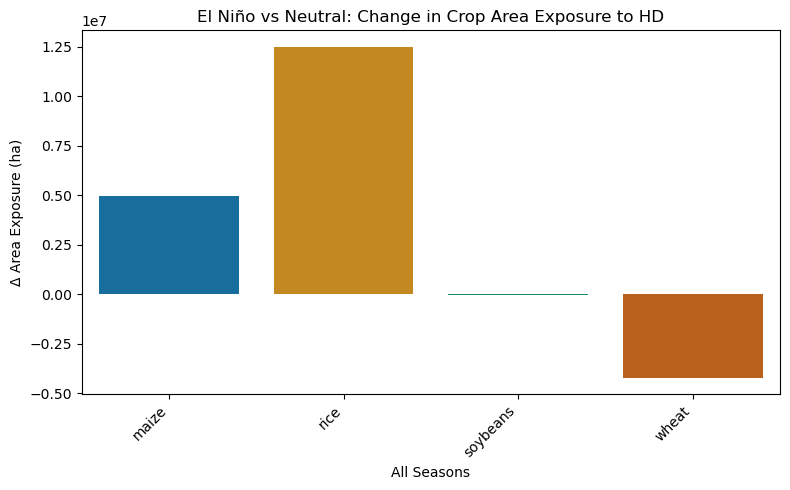

In [72]:
# 2) Filter to just the El Niño – Neutral delta
wide_el = wide[['crop','el_minus_ne']].copy()

# 3) Create the barplot
plt.figure(figsize=(8,5))
sns.barplot(
    data=wide_el,
    x='crop',
    y='el_minus_ne',
    palette='colorblind'
)

# 4) Labels & title
plt.xlabel('All Seasons')
plt.ylabel('Δ Area Exposure (ha)')
plt.title('El Niño vs Neutral: Change in Crop Area Exposure to HD')
plt.xticks(rotation=45, ha='right')  # if names overlap

plt.tight_layout()
plt.show()

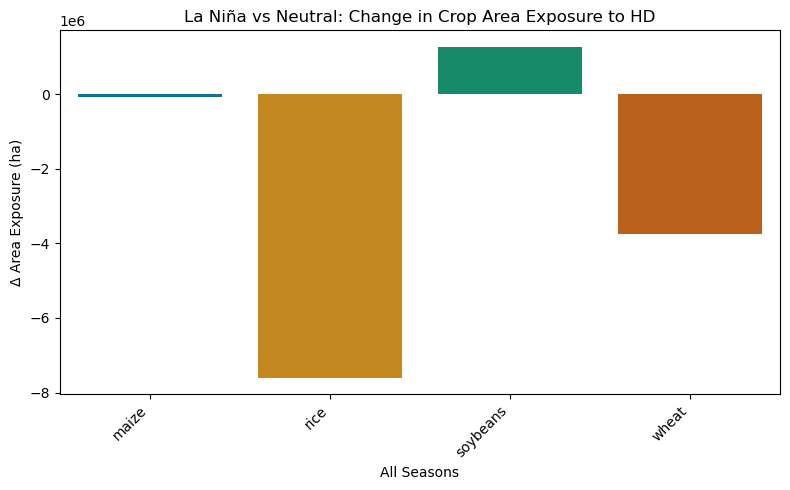

In [73]:
# 2) Filter to just the El Niño – Neutral delta
wide_la = wide[['crop','la_minus_ne']].copy()

# 3) Create the barplot
plt.figure(figsize=(8,5))
sns.barplot(
    data=wide_la,
    x='crop',
    y='la_minus_ne',
    palette='colorblind'
)

# 4) Labels & title
plt.xlabel('All Seasons')
plt.ylabel('Δ Area Exposure (ha)')
plt.title('La Niña vs Neutral: Change in Crop Area Exposure to HD')
plt.xticks(rotation=45, ha='right')  # if names overlap

plt.tight_layout()
plt.show()

In [74]:
crop_areas_hd_annual.to_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_areas_hd_annual.csv', index=False)

In [75]:
# Replace the path with wherever you saved the CSV
csv_path = '/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_areas_by_gs_hw.csv'

# Load into a DataFrame
crop_areas_by_gs_hw = pd.read_csv(csv_path)
crop_areas_by_gs_hw

# A) Compute one “annual” mean per crop/phase/year:
crop_areas_hw_annual = (
    crop_areas_by_gs_hw
    .groupby(['crop','enso_phase','year_index'])['area_ha']
    .mean()
    .reset_index(name='annual_mean_area')
)

# B) Then compute the overall ENSO-phase mean per crop:
crop_areas_hw_summary = (
    crop_areas_hw_annual
    .groupby(['crop','enso_phase'])['annual_mean_area']
    .mean()
    .reset_index(name='mean_exposure_all_years')
)

crop_areas_hw_summary

# 2) Define how each variety should be “clubbed” together
mapping = {
    'maize':        'maize',
    'maize2':       'maize',
    'rice':         'rice',
    'rice2':        'rice',
    'soybeans':     'soybeans',      # leave un-changed
    'wheat':        'wheat',
    'wheatwinter':  'wheat'
}

# 3) Map to a new column
crop_areas_hw_summary['crop_group'] = crop_areas_hw_summary['crop'].map(mapping)

# 4) Aggregate by crop_group & ENSO phase, summing mean_exposure
agg = (
    crop_areas_hw_summary
    .groupby(['crop_group','enso_phase'], as_index=False)
    ['mean_exposure_all_years']
    .sum()
    .rename(columns={'crop_group':'crop'})
)

agg

,crop,enso_phase,mean_exposure_all_years
0,maize,el,1.901257e+07
1,maize,la,1.141678e+07
2,maize,ne,1.335410e+07
3,rice,el,1.526910e+07
4,rice,la,8.743627e+06
5,rice,ne,1.098121e+07
6,soybeans,el,1.136910e+07
7,soybeans,la,4.511988e+06
8,soybeans,ne,7.636343e+06
9,wheat,el,3.271215e+07


In [76]:
# 1) Pivot so we have one row per crop, columns for each phase
wide = (
    agg
    .pivot(index='crop', columns='enso_phase', values='mean_exposure_all_years')
    .reset_index()
)

# 2) Compute the deltas
wide['el_minus_ne'] = wide['el'] - wide['ne']
wide['la_minus_ne'] = wide['la'] - wide['ne']

# 3) (Optional) tidy up column order
wide = wide[['crop', 'el', 'la', 'ne', 'el_minus_ne', 'la_minus_ne']]

wide

enso_phase,crop,el,la,ne,el_minus_ne,la_minus_ne
0,maize,1.901257e+07,1.141678e+07,1.335410e+07,5.658468e+06,-1.937318e+06
1,rice,1.526910e+07,8.743627e+06,1.098121e+07,4.287886e+06,-2.237585e+06
2,soybeans,1.136910e+07,4.511988e+06,7.636343e+06,3.732758e+06,-3.124355e+06
3,wheat,3.271215e+07,1.754465e+07,2.106304e+07,1.164911e+07,-3.518399e+06


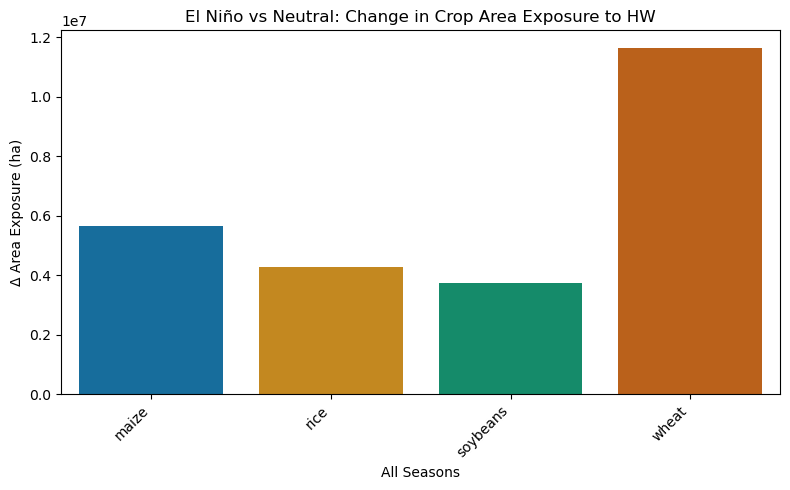

In [77]:
# 2) Filter to just the El Niño – Neutral delta
wide_el = wide[['crop','el_minus_ne']].copy()

# 3) Create the barplot
plt.figure(figsize=(8,5))
sns.barplot(
    data=wide_el,
    x='crop',
    y='el_minus_ne',
    palette='colorblind'
)

# 4) Labels & title
plt.xlabel('All Seasons')
plt.ylabel('Δ Area Exposure (ha)')
plt.title('El Niño vs Neutral: Change in Crop Area Exposure to HW')
plt.xticks(rotation=45, ha='right')  # if names overlap

plt.tight_layout()
plt.show()

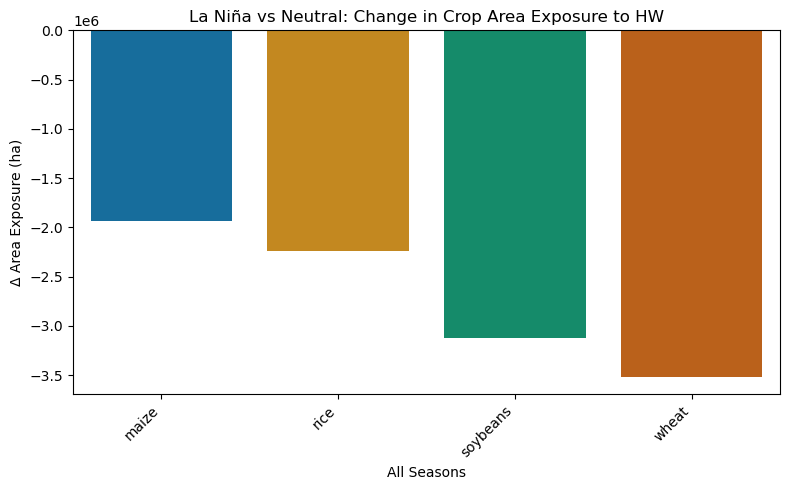

In [78]:
# 2) Filter to just the El Niño – Neutral delta
wide_la = wide[['crop','la_minus_ne']].copy()

# 3) Create the barplot
plt.figure(figsize=(8,5))
sns.barplot(
    data=wide_la,
    x='crop',
    y='la_minus_ne',
    palette='colorblind'
)

# 4) Labels & title
plt.xlabel('All Seasons')
plt.ylabel('Δ Area Exposure (ha)')
plt.title('La Niña vs Neutral: Change in Crop Area Exposure to HW')
plt.xticks(rotation=45, ha='right')  # if names overlap

plt.tight_layout()
plt.show()

In [79]:
crop_areas_hw_annual.to_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_areas_hw_annual.csv', index=False)

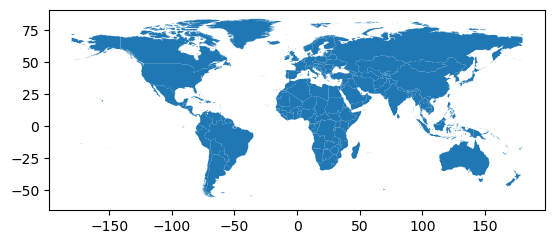

In [80]:
# Specify the path to your shapefile
shapefile_path = '/home/madhulika.gurazada/paper2/Data/Country_polygons/world-administrative-boundaries.shp'

# Load the shapefile using geopandas
cont = gpd.read_file(shapefile_path)

# Plot the shapefile
cont.plot()
plt.show()

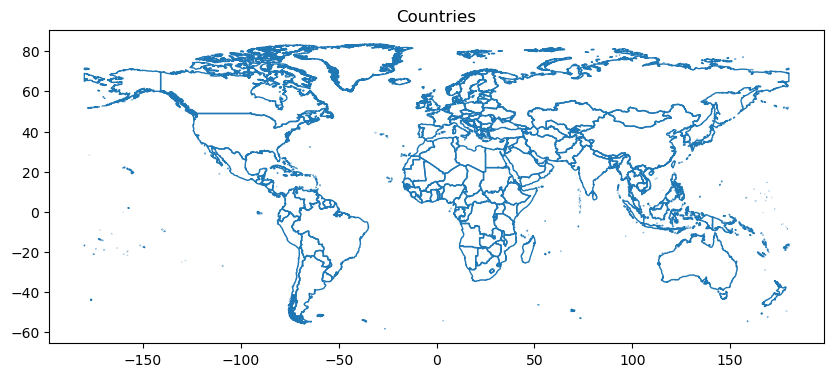

In [81]:
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the shapefile with acronyms
cont.boundary.plot(ax=ax, linewidth=1)  # Plot the boundaries without filling
# cont.apply(lambda x: ax.text(x.geometry.centroid.x, x.geometry.centroid.y, x['name'], fontsize=8, ha='center'), axis=1)

# Add labels and title
plt.title('Countries')

# Show the plot
plt.show()

In [82]:
# ─── Load regions ───────────────────────────────────────────────────────────
cont = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
regions = regionmask.Regions(
    name     = "countries",
    numbers  = cont.index.values,
    names    = cont["name"].values.tolist(),
    outlines = cont.geometry.values
)

# ─── Input lists ────────────────────────────────────────────────────────────
crops  = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']
phases = ['el', 'la', 'ne']
hd_seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# ─── Season to months and year offsets ──────────────────────────────────────
season_info = {
    'jja':   {'months': ['06', '07', '08'], 'offset': 0},
    'son':   {'months': ['09', '10', '11'], 'offset': 0},
    'djf':   {'months': ['12', '01', '02'], 'offset': 1},
    'mam1':  {'months': ['03', '04', '05'], 'offset': 1},
    'jja1':  {'months': ['06', '07', '08'], 'offset': 1},
    'son1':  {'months': ['09', '10', '11'], 'offset': 1},
}

month_doy_ranges = {
    '01': [(1, 31)],   '02': [(32, 59)],   '03': [(60, 90)],
    '04': [(91, 120)], '05': [(121, 151)], '06': [(152, 181)],
    '07': [(182, 212)],'08': [(213, 243)], '09': [(244, 273)],
    '10': [(274, 304)],'11': [(305, 334)], '12': [(335, 365)]
}

# ─── Build growing season mask ──────────────────────────────────────────────
def build_gmask(crop, season):
    plant = plant_dates_all[crop]
    harvest = harvest_dates_all[crop]
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)

    months = season_info[season]['months']
    mask = xr.zeros_like(plant, dtype=bool)
    for m in months:
        for doy_start, doy_end in month_doy_ranges[m]:
            mask |= (plant <= doy_end) & (harvest_adj >= doy_start)
    return mask

# ─── Main Loop ──────────────────────────────────────────────────────────────
records = []

for crop in crops:
    print(f"Crop: {crop}")
    area = coarse_crop_areas[crop]

    # Precompute growing season masks
    season_gmasks = {}
    for season in hd_seasons:
        gmask = build_gmask(crop, season)
        gmask = gmask.reindex(latitude=area.latitude, longitude=area.longitude, method='nearest')\
                     .fillna(False).astype(bool)
        season_gmasks[season] = gmask

    for phase in phases:
        print(f"  Phase: {phase}")
        for enso_year in hot_dry_conditions[phase]['jja'].year.values:
            expos = []

            for season in hd_seasons:
                try:
                    hd_ds = hot_dry_conditions[phase][season]
                    target_year = enso_year + season_info[season]['offset']

                    if target_year not in hd_ds.year.values:
                        continue
                    year_idx = int((hd_ds.year == target_year).argmax().item())

                    hd = (
                        hd_ds
                        .isel(year=year_idx)
                        .rename({'lat': 'latitude', 'lon': 'longitude'})
                        .reindex(latitude=area.latitude, longitude=area.longitude, method='nearest')
                        .fillna(False).astype(bool)
                    )

                    expo = area.where(hd & season_gmasks[season], 0.0)
                    expos.append(expo)

                except Exception:
                    continue

            if not expos:
                continue

            avg_expo = xr.concat(expos, dim="season").mean(dim="season")
            country_mask = regions.mask(avg_expo.longitude, avg_expo.latitude)

            for region_number, country_name in zip(regions.numbers, regions.names):
                total_ha = float(
                    avg_expo.where(country_mask == region_number)
                            .sum(dim=('latitude', 'longitude'), skipna=True)
                            .item()
                )
                crop_area_country = float(
                    area.where(country_mask == region_number)
                        .sum(dim=('latitude', 'longitude'), skipna=True)
                        .item()
                )
                normalized = total_ha / crop_area_country if crop_area_country > 0 else 0.0

                records.append({
                    'crop': crop,
                    'enso_phase': phase,
                    'enso_year': int(enso_year),
                    'country': country_name,
                    'area_exposed_ha': total_ha,
                    'total_crop_area_ha': crop_area_country,
                    'normalized_exposure_percent': normalized * 100
                })

# ─── Save ───────────────────────────────────────────────────────────────────
df = pd.DataFrame(records)
df.to_csv(
    '/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_country_hd_exposure.csv',
    index=False
)
print("✅ Hot-dry multiseason exposure written to CSV with total area and normalized percent.")

Crop: maize
  Phase: el
  Phase: la
  Phase: ne
Crop: maize2
  Phase: el
  Phase: la
  Phase: ne
Crop: rice
  Phase: el
  Phase: la
  Phase: ne
Crop: rice2
  Phase: el
  Phase: la
  Phase: ne
Crop: soybeans
  Phase: el
  Phase: la
  Phase: ne
Crop: wheat
  Phase: el
  Phase: la
  Phase: ne
Crop: wheatwinter
  Phase: el
  Phase: la
  Phase: ne
✅ Hot-dry multiseason exposure written to CSV with total area and normalized percent.


In [83]:
# ─── Load regions ───────────────────────────────────────────────────────────
cont = gpd.read_file(shapefile_path).to_crs("EPSG:4326")
regions = regionmask.Regions(
    name     = "countries",
    numbers  = cont.index.values,
    names    = cont["name"].values.tolist(),
    outlines = cont.geometry.values
)

# ─── Input lists ────────────────────────────────────────────────────────────
crops  = ['maize', 'maize2', 'rice', 'rice2', 'soybeans', 'wheat', 'wheatwinter']
phases = ['el', 'la', 'ne']
hw_seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# ─── Season to months and year offsets ──────────────────────────────────────
season_info = {
    'jja':   {'months': ['06', '07', '08'], 'offset': 0},
    'son':   {'months': ['09', '10', '11'], 'offset': 0},
    'djf':   {'months': ['12', '01', '02'], 'offset': 1},
    'mam1':  {'months': ['03', '04', '05'], 'offset': 1},
    'jja1':  {'months': ['06', '07', '08'], 'offset': 1},
    'son1':  {'months': ['09', '10', '11'], 'offset': 1},
}

month_doy_ranges = {
    '01': [(1, 31)],   '02': [(32, 59)],   '03': [(60, 90)],
    '04': [(91, 120)], '05': [(121, 151)], '06': [(152, 181)],
    '07': [(182, 212)],'08': [(213, 243)], '09': [(244, 273)],
    '10': [(274, 304)],'11': [(305, 334)], '12': [(335, 365)]
}

# ─── Build growing season mask ──────────────────────────────────────────────
def build_gmask(crop, season):
    plant = plant_dates_all[crop]
    harvest = harvest_dates_all[crop]
    harvest_adj = harvest.where(harvest >= plant, harvest + 365)

    months = season_info[season]['months']
    mask = xr.zeros_like(plant, dtype=bool)
    for m in months:
        for doy_start, doy_end in month_doy_ranges[m]:
            mask |= (plant <= doy_end) & (harvest_adj >= doy_start)
    return mask

# ─── Main Loop ──────────────────────────────────────────────────────────────
records = []

for crop in crops:
    print(f"Crop: {crop}")
    area = coarse_crop_areas[crop]

    # Precompute growing season masks
    season_gmasks = {}
    for season in hw_seasons:
        gmask = build_gmask(crop, season)
        gmask = gmask.reindex(latitude=area.latitude, longitude=area.longitude, method='nearest')\
                     .fillna(False).astype(bool)
        season_gmasks[season] = gmask

    for phase in phases:
        print(f"  Phase: {phase}")
        for enso_year in hot_wet_conditions[phase]['jja'].year.values:
            expos = []

            for season in hw_seasons:
                try:
                    hw_ds = hot_wet_conditions[phase][season]
                    target_year = enso_year + season_info[season]['offset']

                    if target_year not in hw_ds.year.values:
                        continue
                    year_idx = int((hw_ds.year == target_year).argmax().item())

                    hw = (
                        hw_ds
                        .isel(year=year_idx)
                        .rename({'lat': 'latitude', 'lon': 'longitude'})
                        .reindex(latitude=area.latitude, longitude=area.longitude, method='nearest')
                        .fillna(False).astype(bool)
                    )

                    expo = area.where(hw & season_gmasks[season], 0.0)
                    expos.append(expo)

                except Exception:
                    continue

            if not expos:
                continue

            avg_expo = xr.concat(expos, dim="season").mean(dim="season")
            country_mask = regions.mask(avg_expo.longitude, avg_expo.latitude)

            for region_number, country_name in zip(regions.numbers, regions.names):
                total_ha = float(
                    avg_expo.where(country_mask == region_number)
                            .sum(dim=('latitude', 'longitude'), skipna=True)
                            .item()
                )
                crop_area_country = float(
                    area.where(country_mask == region_number)
                        .sum(dim=('latitude', 'longitude'), skipna=True)
                        .item()
                )
                normalized = total_ha / crop_area_country if crop_area_country > 0 else 0.0

                records.append({
                    'crop': crop,
                    'enso_phase': phase,
                    'enso_year': int(enso_year),
                    'country': country_name,
                    'area_exposed_ha': total_ha,
                    'total_crop_area_ha': crop_area_country,
                    'normalized_exposure_percent': normalized * 100
                })

# ─── Save ───────────────────────────────────────────────────────────────────
df = pd.DataFrame(records)
df.to_csv(
    '/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_country_hw_exposure.csv',
    index=False
)
print("✅ Hot-wet multiseason exposure written to CSV with total area and normalized percent.")

Crop: maize
  Phase: el
  Phase: la
  Phase: ne
Crop: maize2
  Phase: el
  Phase: la
  Phase: ne
Crop: rice
  Phase: el
  Phase: la
  Phase: ne
Crop: rice2
  Phase: el
  Phase: la
  Phase: ne
Crop: soybeans
  Phase: el
  Phase: la
  Phase: ne
Crop: wheat
  Phase: el
  Phase: la
  Phase: ne
Crop: wheatwinter
  Phase: el
  Phase: la
  Phase: ne
✅ Hot-wet multiseason exposure written to CSV with total area and normalized percent.


In [101]:
# 1) Load the CSV you just wrote
df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_country_hd_exposure.csv')
df = df[df['crop'].isin(['maize', 'rice', 'soybeans', 'wheat'])]

df_mean = (
    df
    .groupby(['crop','enso_phase','country'], as_index=False)[['area_exposed_ha', 'total_crop_area_ha', 'normalized_exposure_percent']]
    .mean()
)
# df_mean[df_mean['country'] == 'India']

df_hd = df_mean.pivot_table(
    index=['crop', 'country'],
    columns='enso_phase',
    values=['area_exposed_ha', 'normalized_exposure_percent']
).reset_index()

df_hd

# Flatten the multi-index columns
df_hd.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_hd.columns]
df_hd.columns.name = None

# Differences for area_exposed_ha
df_hd['area_exposed_ha_el_minus_ne'] = df_hd['area_exposed_ha_el'] - df_hd['area_exposed_ha_ne']
df_hd['area_exposed_ha_la_minus_ne'] = df_hd['area_exposed_ha_la'] - df_hd['area_exposed_ha_ne']

# Differences for normalized_exposure_percent
df_hd['normalized_exposure_percent_el_minus_ne'] = (
    df_hd['normalized_exposure_percent_el'] - df_hd['normalized_exposure_percent_ne']
)
df_hd['normalized_exposure_percent_la_minus_ne'] = (
    df_hd['normalized_exposure_percent_la'] - df_hd['normalized_exposure_percent_ne']
)

df_hd

,crop_,country_,area_exposed_ha_el,area_exposed_ha_la,area_exposed_ha_ne,normalized_exposure_percent_el,normalized_exposure_percent_la,normalized_exposure_percent_ne,area_exposed_ha_el_minus_ne,area_exposed_ha_la_minus_ne,normalized_exposure_percent_el_minus_ne,normalized_exposure_percent_la_minus_ne
0,maize,Abyei,0.063650,0.061831,0.033947,3.431373,3.333333,1.830065,0.029703,0.027885,1.601307,1.503268
1,maize,Afghanistan,1535.475592,2558.636135,1280.887233,1.382176,2.303186,1.153005,254.588359,1277.748902,0.229171,1.150180
2,maize,Aksai Chin,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,maize,Albania,2332.532404,3034.430333,3304.065399,3.929512,5.111968,5.566210,-971.532995,-269.635066,-1.636698,-0.454242
4,maize,Algeria,26.780130,22.759355,21.732901,4.870954,4.139628,3.952929,5.047229,1.026454,0.918025,0.186698
...,...,...,...,...,...,...,...,...,...,...,...,...
1019,wheat,West Bank,13.316235,12.448029,18.896172,1.176471,1.099766,1.669450,-5.579937,-6.448143,-0.492980,-0.569684
1020,wheat,Western Sahara,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1021,wheat,Yemen,2246.383402,1720.631241,1537.311292,4.208983,3.223897,2.880415,709.072110,183.319949,1.328568,0.343481
1022,wheat,Zambia,280.826173,5.755329,210.353582,1.083101,0.022197,0.811300,70.472591,-204.598253,0.271801,-0.789102


In [85]:
# Bootstrap function (as before)
def bootstrap_p_value(s1, s2, n_bootstrap=1000):
    s1 = s1.dropna()
    s2 = s2.dropna()
    obs_diff = s1.mean() - s2.mean()
    combined = pd.concat([s1, s2])
    boot_diffs = []
    for _ in range(n_bootstrap):
        b1 = combined.sample(len(s1), replace=True)
        b2 = combined.sample(len(s2), replace=True)
        boot_diffs.append(b1.mean() - b2.mean())
    p_val = np.mean(np.abs(boot_diffs) >= np.abs(obs_diff))
    return obs_diff, p_val

In [86]:
# Parameters
phase_pairs = [('el', 'ne'), ('la', 'ne')]
alpha = 0.10

# Prepare a list to collect results
records = []

# Loop over crops, countries, and phase comparisons
for crop in df['crop'].unique():
    df_crop = df[df['crop'] == crop]
    for country in df_crop['country'].unique():
        df_cc = df_crop[df_crop['country'] == country]
        for phase1, phase2 in phase_pairs:
            s1 = df_cc.loc[df_cc['enso_phase'] == phase1, 'area_exposed_ha']
            s2 = df_cc.loc[df_cc['enso_phase'] == phase2, 'area_exposed_ha']
            s1_norm = df_cc.loc[df_cc['enso_phase'] == phase1, 'normalized_exposure_percent']
            s2_norm = df_cc.loc[df_cc['enso_phase'] == phase2, 'normalized_exposure_percent']

            if len(s1.dropna()) > 0 and len(s2.dropna()) > 0:
                diff, p_val = bootstrap_p_value(s1, s2, n_bootstrap=1000)
                diff_norm, p_norm = bootstrap_p_value(s1_norm, s2_norm, n_bootstrap=1000)

                records.append({
                    'crop': crop,
                    'country': country,
                    'comparison': f"{phase1.upper()}–{phase2.upper()}",
                    'observed_diff_ha_seasons': diff,
                    'p_value_ha': p_val,
                    'significant_ha': p_val < alpha,
                    'observed_diff_normalized_pct': diff_norm,
                    'p_value_norm': p_norm,
                    'significant_norm': p_norm < alpha
                })

# Build the results DataFrame
results_hd = pd.DataFrame.from_records(records)

In [87]:
# 1) Load the CSV you just wrote
df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_country_hw_exposure.csv')
df = df[df['crop'].isin(['maize', 'rice', 'soybeans', 'wheat'])]

df_mean = (
    df
    .groupby(['crop','enso_phase','country'], as_index=False)[['area_exposed_ha', 'total_crop_area_ha', 'normalized_exposure_percent']]
    .mean()
)
# df_mean[df_mean['country'] == 'India']

df_hw = df_mean.pivot_table(
    index=['crop', 'country'],
    columns='enso_phase',
    values=['area_exposed_ha', 'normalized_exposure_percent']
).reset_index()

df_hw

# Flatten the multi-index columns
df_hw.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_hw.columns]
df_hw.columns.name = None

# Differences for area_exposed_ha
df_hw['area_exposed_ha_el_minus_ne'] = df_hw['area_exposed_ha_el'] - df_hw['area_exposed_ha_ne']
df_hw['area_exposed_ha_la_minus_ne'] = df_hw['area_exposed_ha_la'] - df_hw['area_exposed_ha_ne']

# Differences for normalized_exposure_percent
df_hw['normalized_exposure_percent_el_minus_ne'] = (
    df_hw['normalized_exposure_percent_el'] - df_hw['normalized_exposure_percent_ne']
)
df_hw['normalized_exposure_percent_la_minus_ne'] = (
    df_hw['normalized_exposure_percent_la'] - df_hw['normalized_exposure_percent_ne']
)

df_hw

,crop_,country_,area_exposed_ha_el,area_exposed_ha_la,area_exposed_ha_ne,normalized_exposure_percent_el,normalized_exposure_percent_la,normalized_exposure_percent_ne,area_exposed_ha_el_minus_ne,area_exposed_ha_la_minus_ne,normalized_exposure_percent_el_minus_ne,normalized_exposure_percent_la_minus_ne
0,maize,Abyei,0.010911,0.009763,0.006062,0.588235,0.526316,0.326797,0.004850,0.003701,0.261438,0.199518
1,maize,Afghanistan,1273.128181,710.443467,755.351665,1.146021,0.639514,0.679938,517.776516,-44.908198,0.466082,-0.040425
2,maize,Aksai Chin,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,maize,Albania,134.755283,0.000000,413.605664,0.227016,0.000000,0.696783,-278.850381,-413.605664,-0.469767,-0.696783
4,maize,Algeria,2.857185,1.624541,1.636997,0.519684,0.295483,0.297748,1.220187,-0.012456,0.221936,-0.002266
...,...,...,...,...,...,...,...,...,...,...,...,...
1019,wheat,West Bank,0.602101,5.957263,4.037344,0.053195,0.526316,0.356694,-3.435242,1.919919,-0.303499,0.169622
1020,wheat,Western Sahara,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1021,wheat,Yemen,766.153166,1697.718795,486.471677,1.435519,3.180966,0.911488,279.681489,1211.247118,0.524031,2.269478
1022,wheat,Zambia,114.113907,124.880692,98.704785,0.440119,0.481645,0.380688,15.409122,26.175907,0.059430,0.100956


In [88]:
# Parameters
phase_pairs = [('el', 'ne'), ('la', 'ne')]
alpha = 0.10

# Prepare a list to collect results
records1 = []

# Loop over crops, countries, and phase comparisons
for crop in df['crop'].unique():
    df_crop = df[df['crop'] == crop]
    for country in df_crop['country'].unique():
        df_cc = df_crop[df_crop['country'] == country]
        for phase1, phase2 in phase_pairs:
            s1 = df_cc.loc[df_cc['enso_phase'] == phase1, 'area_exposed_ha']
            s2 = df_cc.loc[df_cc['enso_phase'] == phase2, 'area_exposed_ha']
            s1_norm = df_cc.loc[df_cc['enso_phase'] == phase1, 'normalized_exposure_percent']
            s2_norm = df_cc.loc[df_cc['enso_phase'] == phase2, 'normalized_exposure_percent']

            if len(s1.dropna()) > 0 and len(s2.dropna()) > 0:
                diff, p_val = bootstrap_p_value(s1, s2, n_bootstrap=1000)
                diff_norm, p_norm = bootstrap_p_value(s1_norm, s2_norm, n_bootstrap=1000)

                records1.append({
                    'crop': crop,
                    'country': country,
                    'comparison': f"{phase1.upper()}–{phase2.upper()}",
                    'observed_diff_ha_seasons': diff,
                    'p_value_ha': p_val,
                    'significant_ha': p_val < alpha,
                    'observed_diff_normalized_pct': diff_norm,
                    'p_value_norm': p_norm,
                    'significant_norm': p_norm < alpha
                })

# Build the results DataFrame
results_hw = pd.DataFrame.from_records(records1)

In [102]:
df_hd = df_hd.rename(columns={
    'crop_': 'crop',
    'country_': 'country'
})

In [90]:
df_hw = df_hw.rename(columns={
    'crop_': 'crop',
    'country_': 'country'
})

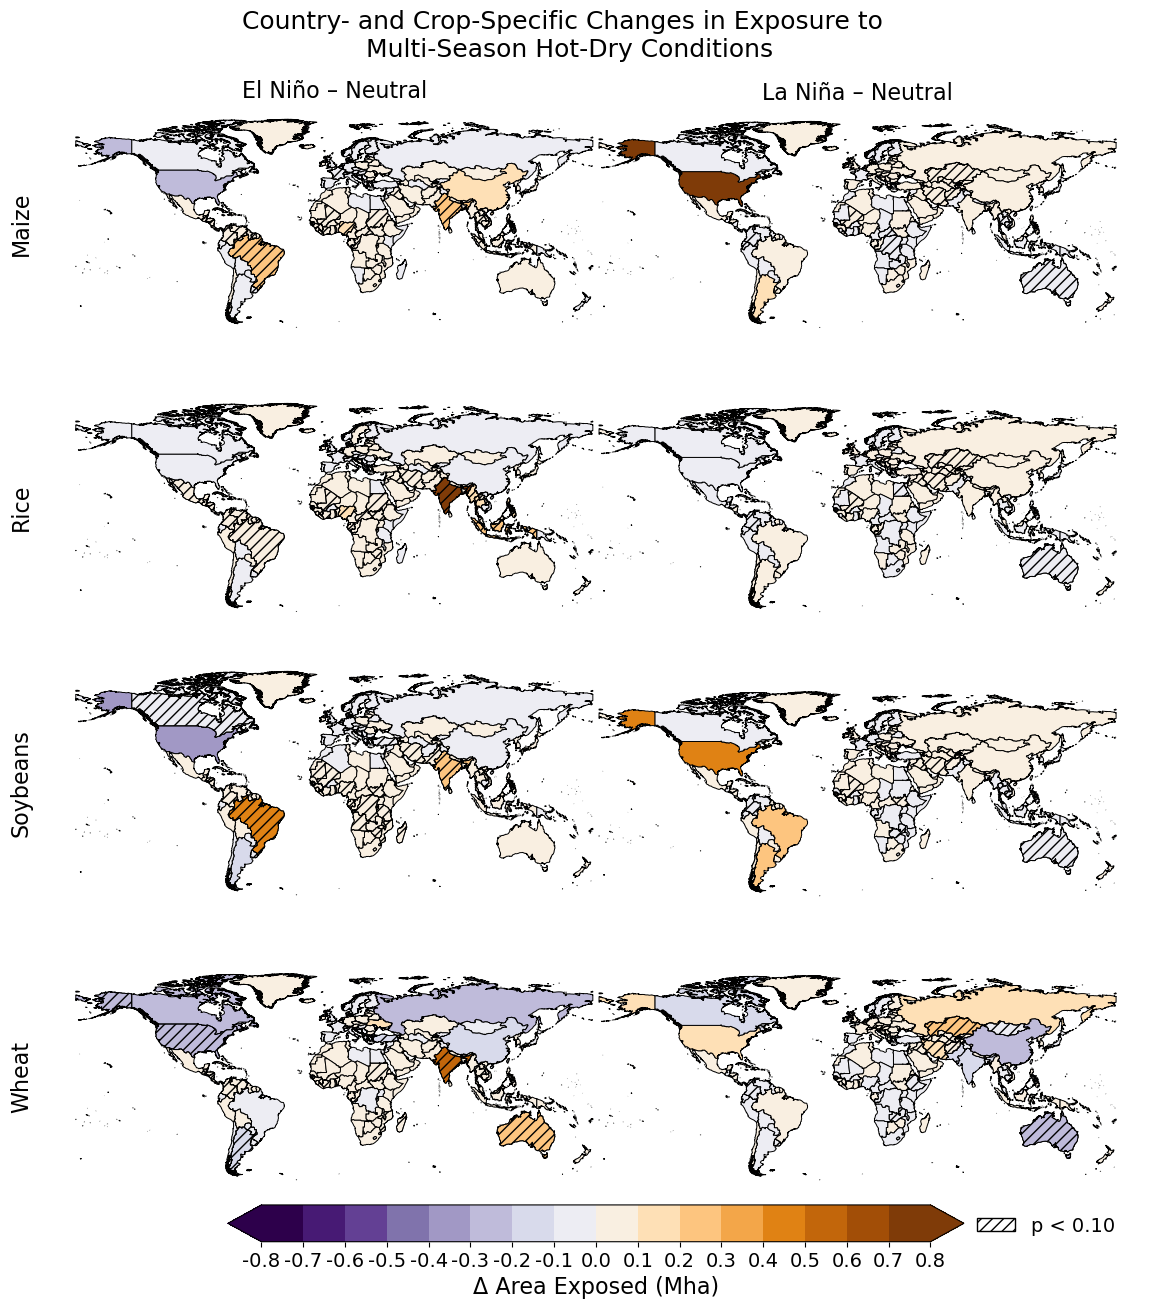

In [103]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# 1) Define rows and columns
crops  = ['maize','rice','soybeans','wheat']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hd[['area_exposed_ha_el_minus_ne','area_exposed_ha_la_minus_ne']].abs().max().max()
step = 100_000
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr_r', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.50
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# convert raw bins → Mha, then make ticks every 0.1 Mha
mlim     = vlim / 1e6
tick_mha = np.arange(-mlim, mlim + 0.1, 0.1)
tick_locs = tick_mha * 1e6
labels = [
    "0.0" if np.isclose(x, 0) else f"{x:.1f}"
    for x in tick_mha
]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.82
)

plt.show()

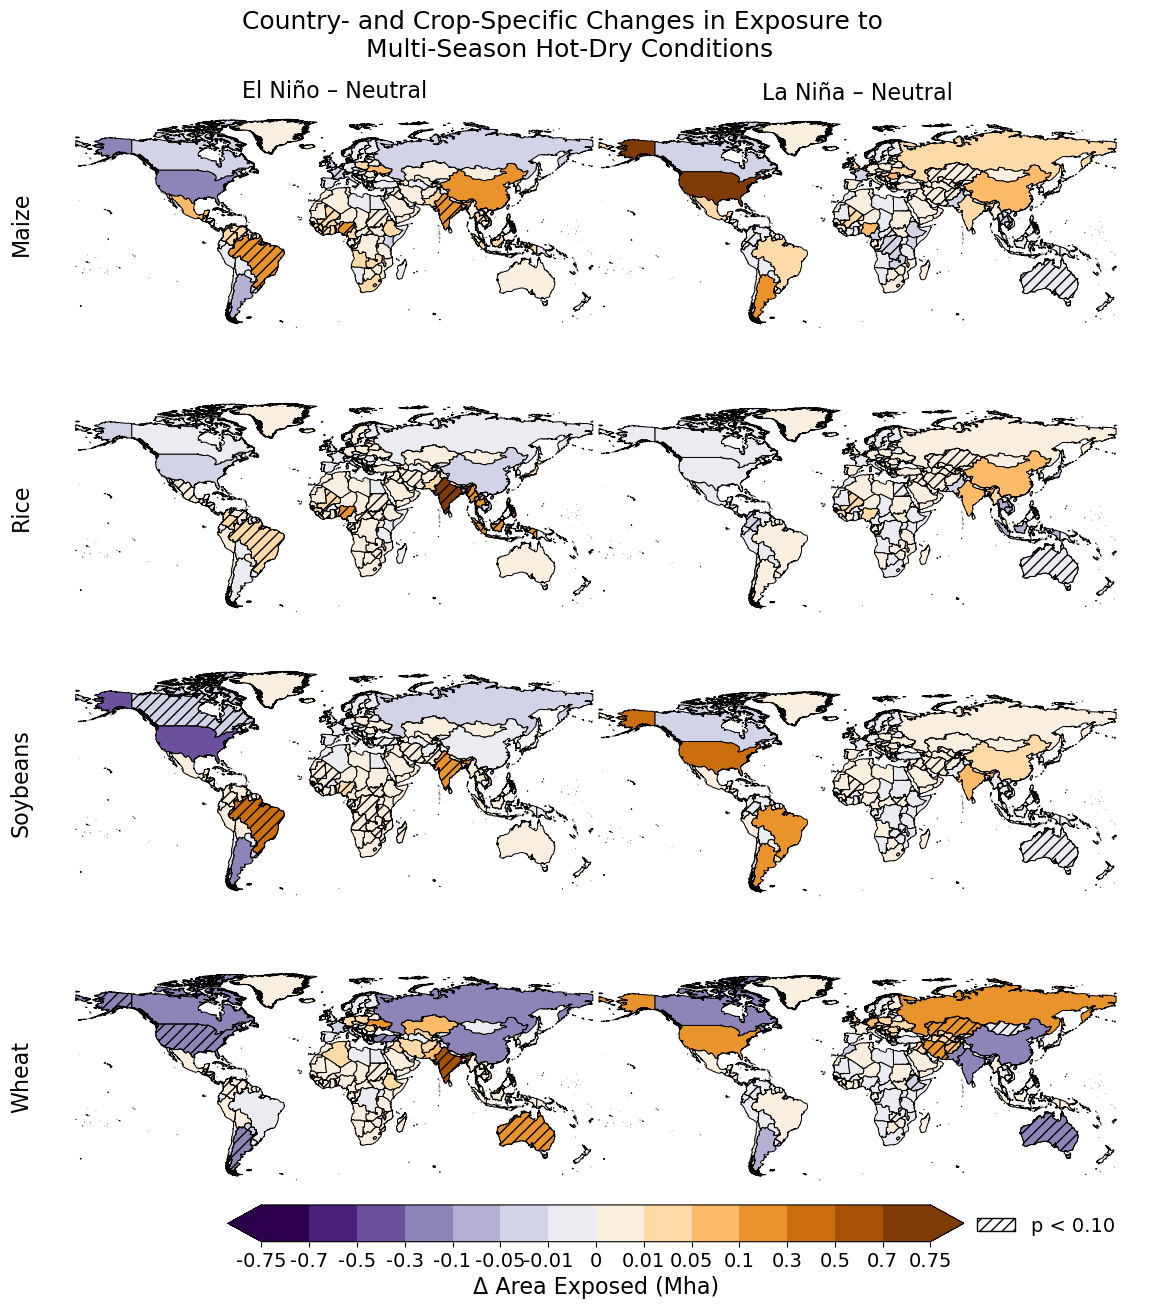

In [104]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# 1) Define rows and columns
crops  = ['maize','rice','soybeans','wheat']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# --- NONLINEAR BIN EDGES (in Mha), denser near 0, up to ±8 Mha ---
# Positive edges you asked for:
pos_edges_mha = [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.75]
# Mirror to negative and combine (sorted, unique, includes 0):
neg_edges_mha = [-e for e in reversed(pos_edges_mha)]
edges_mha = sorted(set(neg_edges_mha + pos_edges_mha))

# If you'd like to clamp outer edges to your data (optional), uncomment:
# vmax_ha = df_hd[['area_exposed_ha_el_minus_ne','area_exposed_ha_la_minus_ne']].abs().max().max()
# mlim = vmax_ha / 1e6
# if mlim < 8:
#     edges_mha = [e for e in edges_mha if abs(e) <= max(0.65, mlim)] + [0.0]
#     edges_mha = sorted(set(edges_mha))

# Convert edges to hectares for the norm
bins = np.array(edges_mha, dtype=float) * 1e6  # must be strictly increasing

# 4) Build discrete colormap & norm (one color per interval)
cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.50
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar using the SAME non-linear edges
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Use the bin edges as tick locations; format nicely in Mha
tick_locs = bins
def fmt_mha(x):
    # x is in Mha already
    if np.isclose(x, 0): return "0"
    if abs(x) >= 1:
        return f"{x:.1f}".rstrip('0').rstrip('.')  # 1, 2, 3.5
    return f"{x:.2f}".rstrip('0').rstrip('.')      # 0.05, 0.10 -> 0.1, 0.25

tick_labels = [fmt_mha(v) for v in (np.array(edges_mha))]

cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'  # show arrows if values go beyond endpoints
)
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.82
)

plt.show()

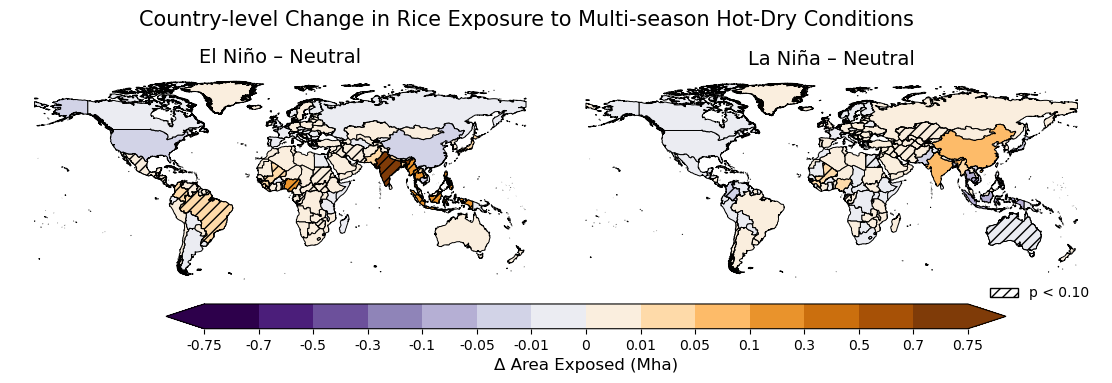

In [119]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# --- Show only RICE ---
crops  = ['rice']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# World boundaries (EPSG:4326)
gdf = gpd.read_file(
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/world-administrative-boundaries.shp'
).to_crs("EPSG:4326")

# --- Nonlinear bin edges in Mha (denser near 0); convert to hectares for the norm ---
pos_edges_mha = [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.75]
neg_edges_mha = [-e for e in reversed(pos_edges_mha)]
edges_mha = sorted(set(neg_edges_mha + pos_edges_mha))          # e.g., [-0.75, ..., -0.01, 0, 0.01, ..., 0.75]
bins = (np.array(edges_mha, dtype=float) * 1e6)                 # hectares for BoundaryNorm

# Discrete colormap & norm
cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# --- Figure: 1 row (rice) × 2 columns (El vs La) ---
fig = plt.figure(figsize=(12, 5.5))
gs = GridSpec(
    nrows=1, ncols=len(phases), figure=fig,
    left=0.07, right=0.98, top=0.86, bottom=0.18, wspace=0.02, hspace=0.0
)

axes = [fig.add_subplot(gs[0, j]) for j in range(len(phases))]

# Plot panels
crop = 'rice'
sub = df_hd[df_hd['crop'] == crop]

for j, (col, title) in enumerate(phases.items()):
    ax = axes[j]
    merged = gdf.merge(sub[['country', col]], left_on='name', right_on='country', how='left')

    merged.plot(column=col, cmap=cmap, norm=norm, linewidth=0.7, edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=14, pad=6)
    ax.axis('off')

    # Hatch significant (p<0.10) from results_hd
    comp = 'EL–NE' if col == 'area_exposed_ha_el_minus_ne' else 'LA–NE'
    sig_countries = results_hd.query("crop==@crop and comparison==@comp and significant_ha")['country']
    merged[merged['country'].isin(sig_countries)].plot(
        ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, hatch="///", zorder=2
    )

# ---- Shared colorbar directly below the maps ----
sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

# Place a long, thick cbar just under the subplot row: [left, bottom, width, height]
cax = fig.add_axes([0.20, 0.25, 0.70, 0.045])

# Tick locations are the bin edges (in hectares); labels in Mha from edges_mha
def fmt_mha(x):
    if np.isclose(x, 0): return "0"
    x = float(x)
    return f"{x:.2f}".rstrip('0').rstrip('.') if abs(x) < 1 else f"{x:.1f}".rstrip('0').rstrip('.')

tick_locs   = bins
tick_labels = [fmt_mha(v) for v in edges_mha]   # labels in Mha

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=tick_locs, extend='both')
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Hatch legend (p<0.10)
hatch = mpatches.Patch(facecolor='none', hatch='///', edgecolor='black', label='p < 0.10')
fig.legend(handles=[hatch], loc='upper right', bbox_to_anchor=(0.98, 0.35), frameon=False, fontsize=10)

# Title
fig.suptitle("Country-level Change in Rice Exposure to Multi-season Hot-Dry Conditions", fontsize=15, y=0.83)

plt.show()

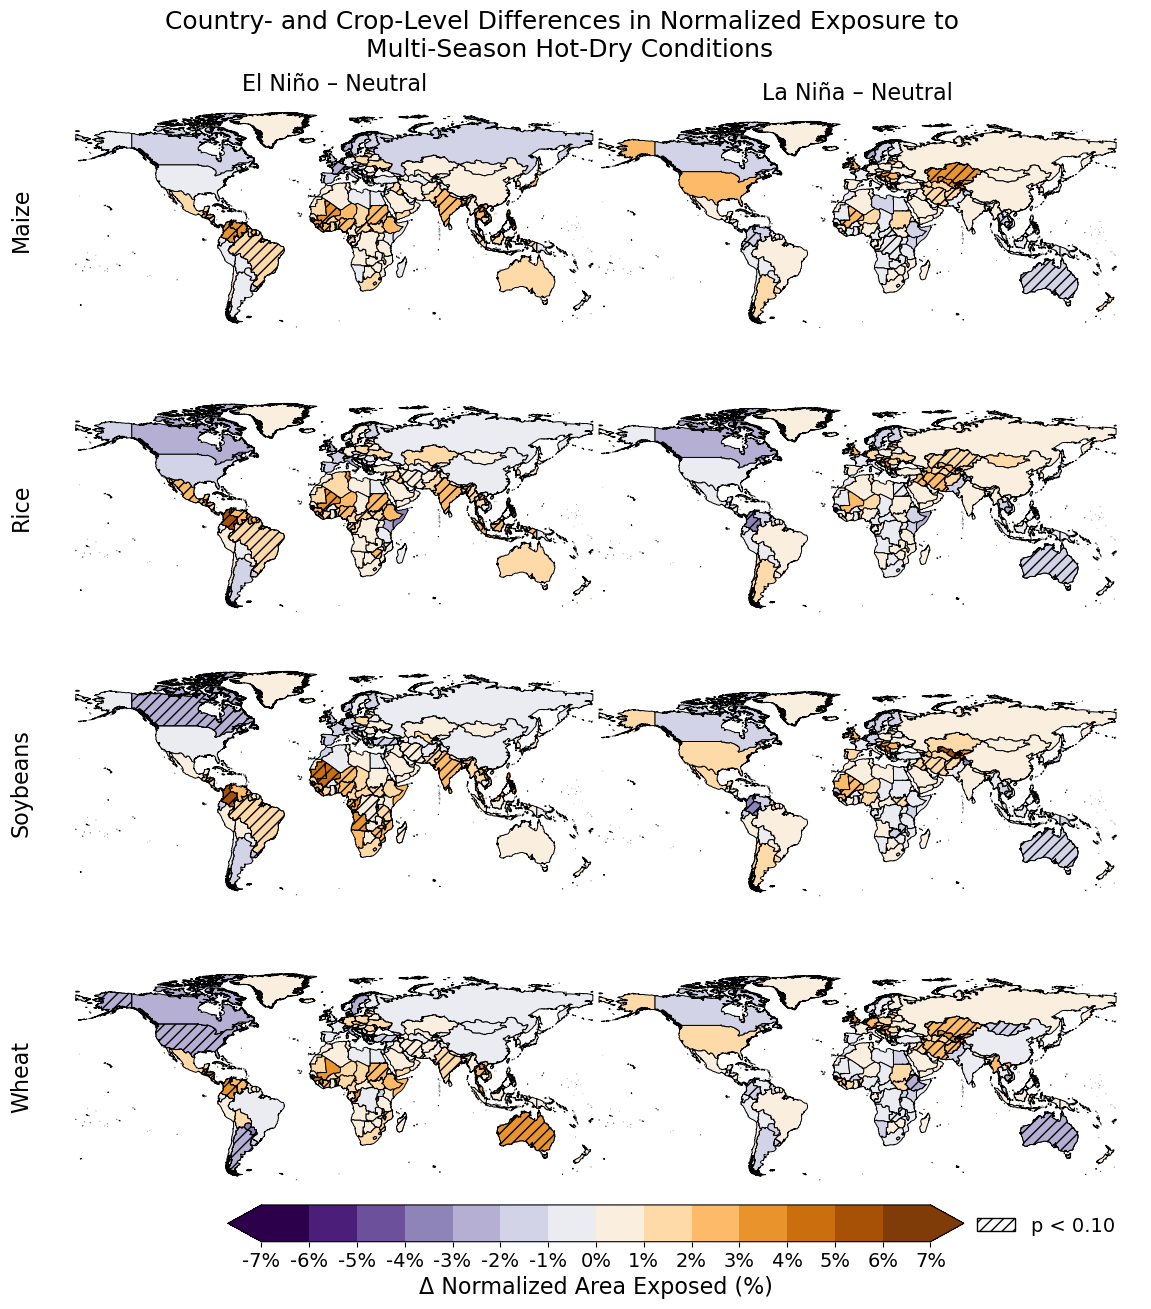

In [120]:
# 1) Define rows and columns
crops  = ['maize','rice','soybeans','wheat']
phases = {
    'normalized_exposure_percent_el_minus_ne': 'El Niño – Neutral',
    'normalized_exposure_percent_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hd[['normalized_exposure_percent_el_minus_ne','normalized_exposure_percent_la_minus_ne']].abs().max().max()
step = 1
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr_r', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.50
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='normalized_exposure_percent_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_norm"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


tick_pct = np.arange(-vlim, vlim + step, step)
labels = [f"{x:.0f}%" if x != 0 else "0%" for x in tick_pct]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_pct,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Normalized Area Exposed (%)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Level Differences in Normalized Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.82
)

plt.show()

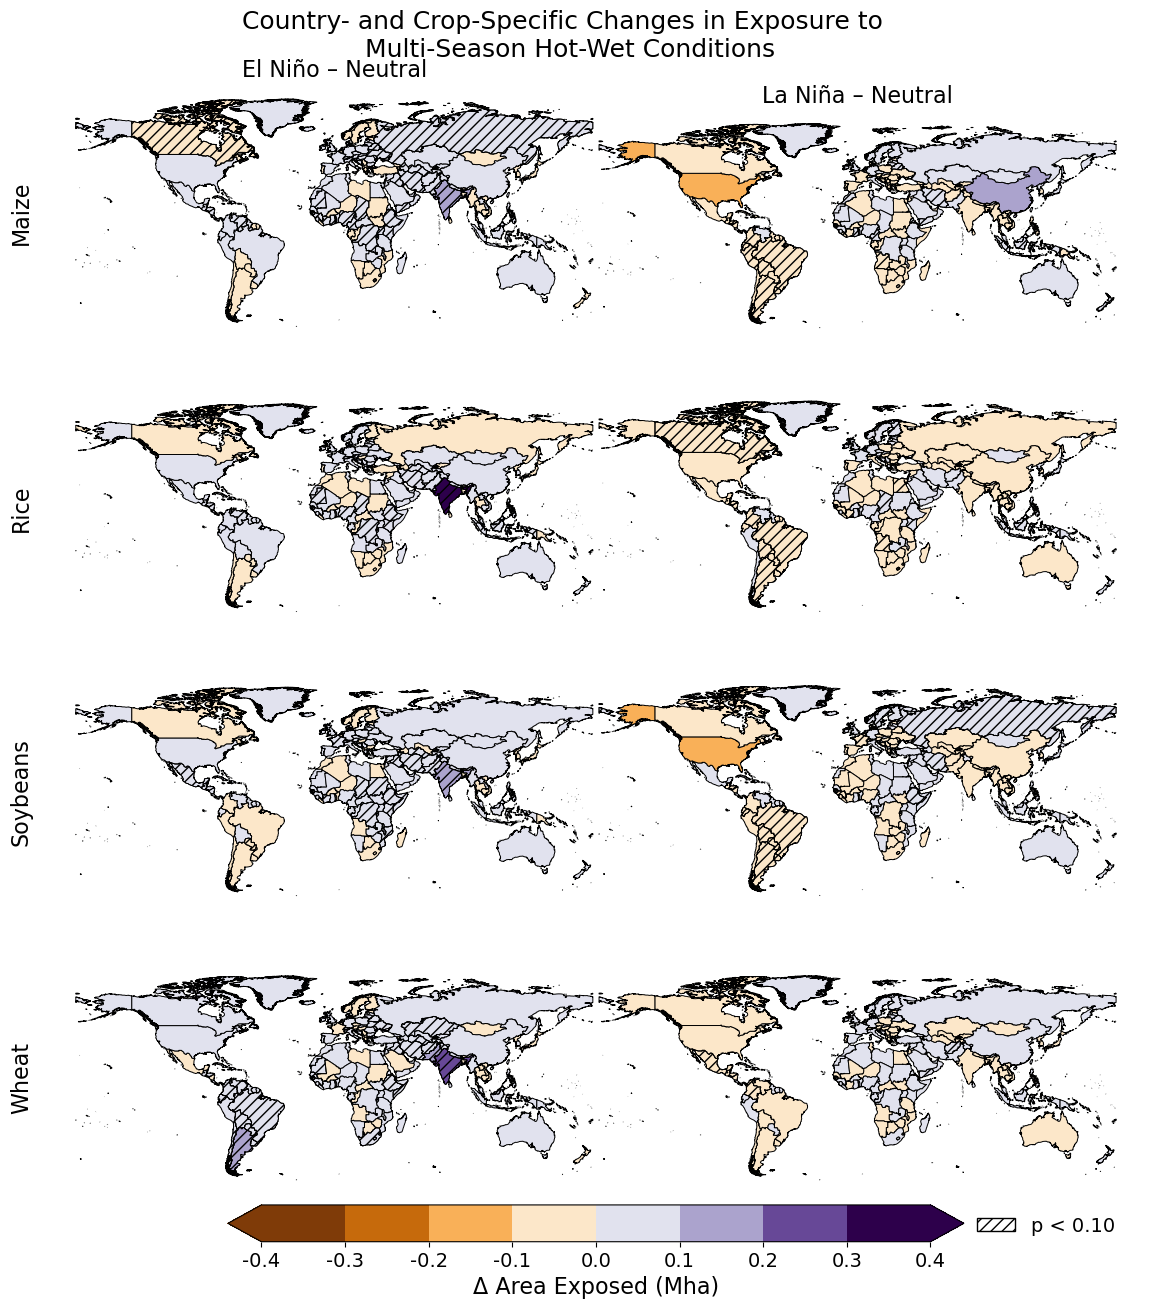

In [121]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# 1) Define rows and columns
crops  = ['maize','rice','soybeans','wheat']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hw[['area_exposed_ha_el_minus_ne','area_exposed_ha_la_minus_ne']].abs().max().max()
step = 100_000
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.50
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# convert raw bins → Mha, then make ticks every 0.1 Mha
mlim     = vlim / 1e6
tick_mha = np.arange(-mlim, mlim + 0.1, 0.1)
tick_locs = tick_mha * 1e6
labels = [
    "0.0" if np.isclose(x, 0) else f"{x:.1f}"
    for x in tick_mha
]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.82
)

plt.show()

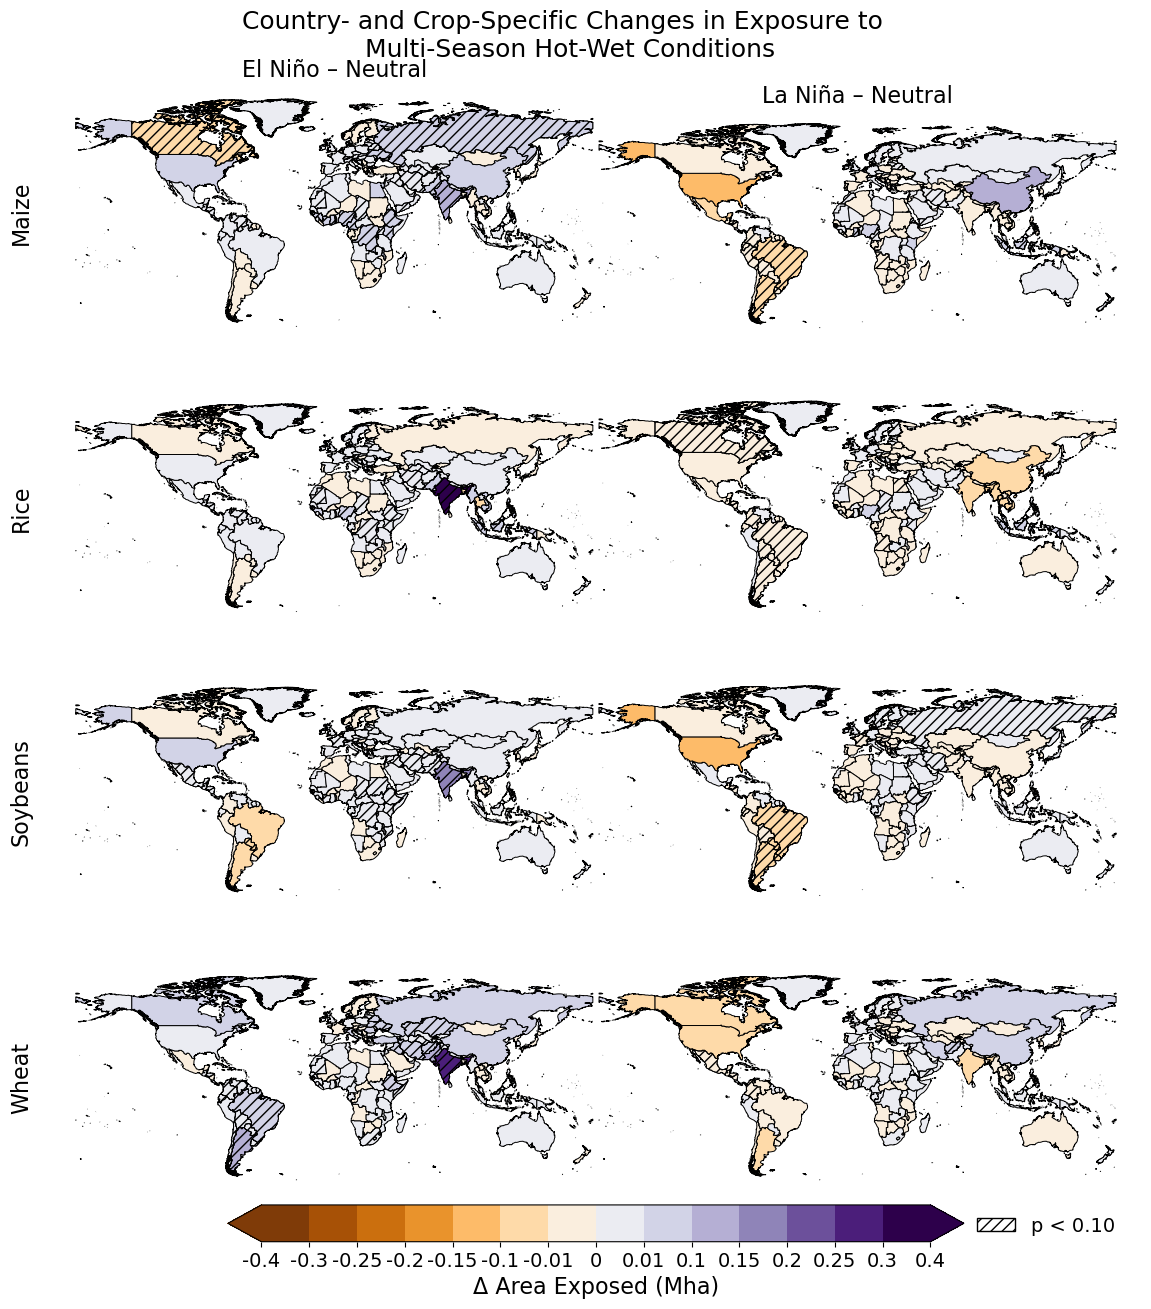

In [96]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Define rows and columns
crops  = ['maize','rice','soybeans','wheat']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) NONLINEAR bin edges in Mha (your spec), then convert to ha
edges_mha = [
    -0.40, -0.30, -0.25, -0.20, -0.15, -0.10, -0.01, 0.00,
     0.01,  0.10,  0.15,  0.20,  0.25,  0.30,  0.40
]
bins = np.array(edges_mha, dtype=float) * 1e6  # convert to ha

# 4) Discrete colormap & norm
cmap = plt.get_cmap('PuOr', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left=0.07, right=0.98, top=0.97, bottom=0.05,
    wspace=-0.08, hspace=-0.50
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black', ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col == 'area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center', rotation=90
    )

# 8) Shared colorbar with NONLINEAR bins + precise formatting
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_locs = bins  # one tick per edge

def fmt_mha(x):
    if np.isclose(x, 0):
        return "0"
    ax = abs(x)
    if ax < 1:
        # one decimal for multiples of 0.1 (0.1, 0.2, 0.3), two decimals otherwise (0.01, 0.15, 0.25)
        if np.isclose((ax * 10) % 1, 0):   # multiple of 0.1
            return f"{x:.1f}"
        else:
            return f"{x:.2f}"
    # ≥ 1 Mha
    return f"{int(x)}" if np.isclose(x, round(x)) else f"{x:.1f}"

tick_labels = [fmt_mha(v) for v in edges_mha]

cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.ax.set_xticklabels(tick_labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.82
)

plt.show()

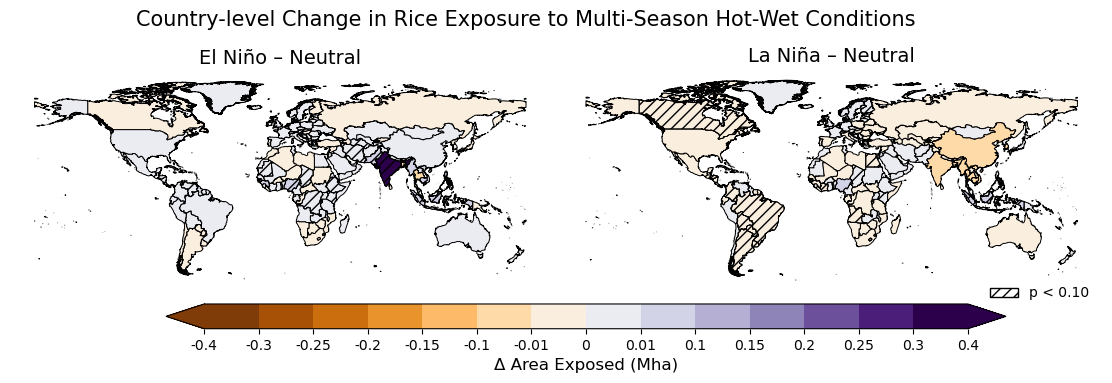

In [124]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Show only RICE ---
crops  = ['rice']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# World boundaries (EPSG:4326)
shapefile_path = '/home/madhulika.gurazada/paper2/Data/Country_polygons/world-administrative-boundaries.shp'
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# --- Nonlinear bin edges in Mha; convert to hectares for the norm ---
edges_mha = [-0.40, -0.30, -0.25, -0.20, -0.15, -0.10, -0.01, 0.00,
              0.01,  0.10,  0.15,  0.20,  0.25,  0.30,  0.40]
bins = np.array(edges_mha, dtype=float) * 1e6  # ha

# Discrete colormap & norm
cmap = plt.get_cmap('PuOr', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# --- Figure: 1 row (rice) × 2 columns (El vs La) ---
fig = plt.figure(figsize=(12, 5.5))
gs = GridSpec(
    nrows=1, ncols=len(phases), figure=fig,
    left=0.07, right=0.98, top=0.86, bottom=0.18, wspace=0.02, hspace=0.0
)
axes = [fig.add_subplot(gs[0, j]) for j in range(len(phases))]

# Plot panels
crop = 'rice'
sub = df_hw[df_hw['crop'] == crop]

for j, (col, title) in enumerate(phases.items()):
    ax = axes[j]
    merged = gdf.merge(sub[['country', col]], left_on='name', right_on='country', how='left')
    merged.plot(column=col, cmap=cmap, norm=norm, linewidth=0.7, edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=14, pad=6)
    ax.axis('off')

    # Hatch significant (p < 0.10) from results_hw
    comp = 'EL–NE' if col == 'area_exposed_ha_el_minus_ne' else 'LA–NE'
    sig_countries = results_hw.query("crop==@crop and comparison==@comp and significant_ha")['country']
    merged[merged['country'].isin(sig_countries)].plot(
        ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, hatch="///", zorder=2
    )

# ---- Shared colorbar directly below the maps ----
sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])

# Long & thick cbar just under the subplot row: [left, bottom, width, height]
cax = fig.add_axes([0.20, 0.25, 0.70, 0.045])

def fmt_mha(x):
    if np.isclose(x, 0): return "0"
    ax = abs(x)
    if ax < 1:
        # one decimal for 0.1, 0.2, 0.3; two decimals for 0.01, 0.15, 0.25
        return f"{x:.1f}" if np.isclose((ax*10) % 1, 0) else f"{x:.2f}"
    return f"{int(x)}" if np.isclose(x, round(x)) else f"{x:.1f}"

tick_locs   = bins
tick_labels = [fmt_mha(v) for v in edges_mha]   # labels in Mha

cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=tick_locs, extend='both')
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Hatch legend (p < 0.10)
hatch = mpatches.Patch(facecolor='none', hatch='///', edgecolor='black', label='p < 0.10')
fig.legend(handles=[hatch], loc='upper right', bbox_to_anchor=(0.98, 0.35), frameon=False, fontsize=10)

# Title
fig.suptitle("Country-level Change in Rice Exposure to Multi-Season Hot-Wet Conditions", fontsize=15, y=0.83)

plt.show()

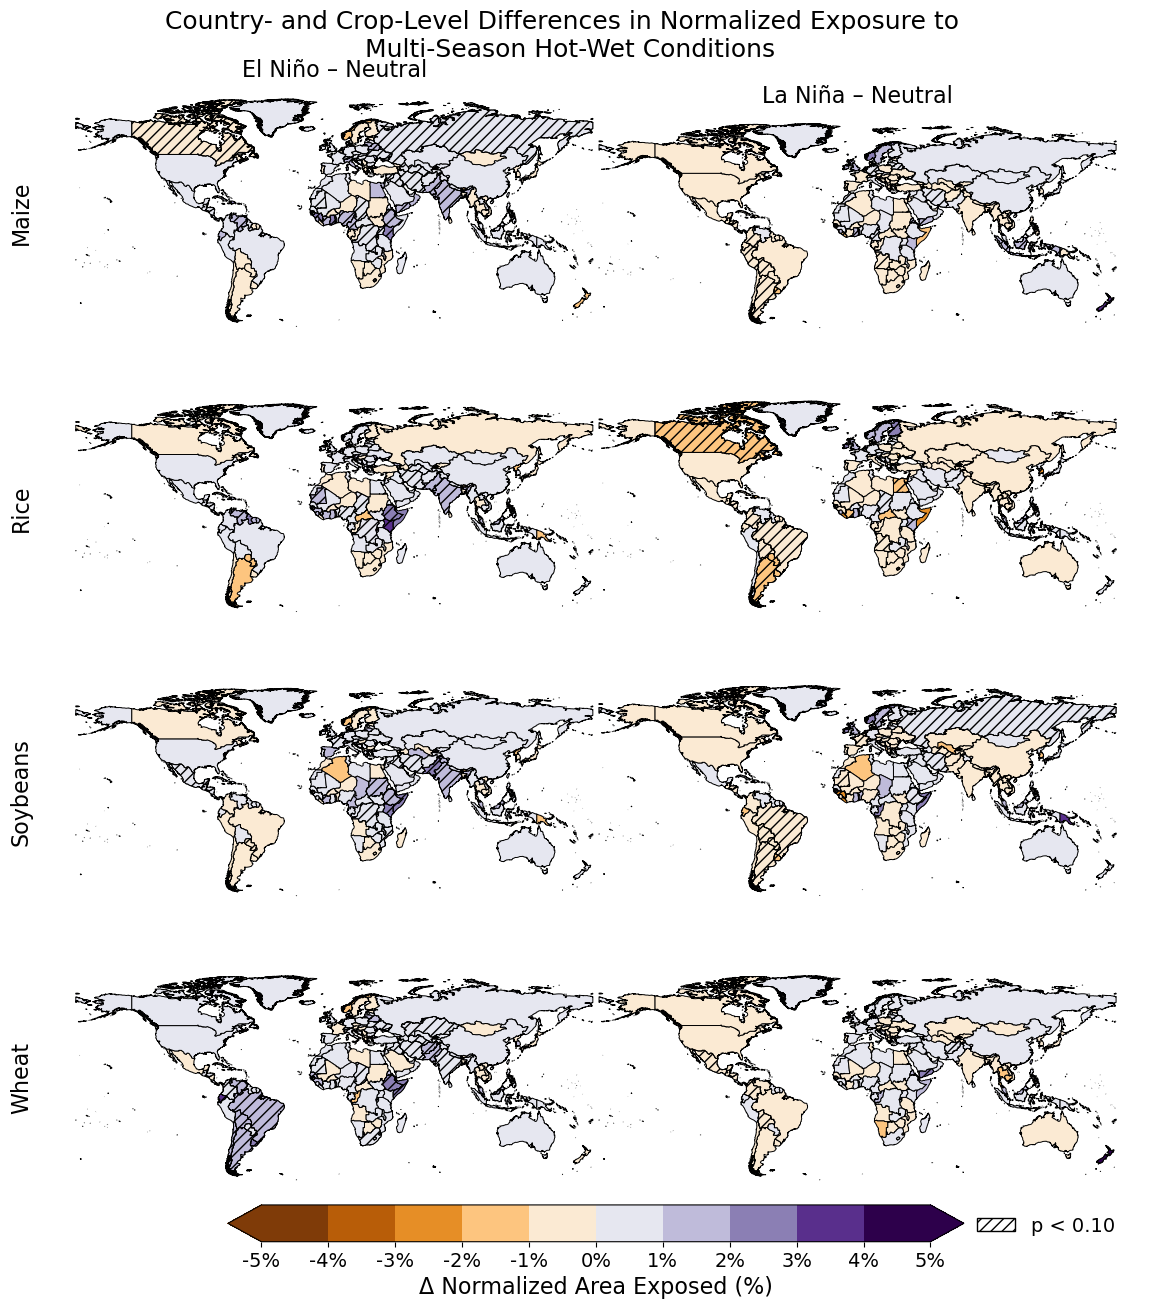

In [97]:
# 1) Define rows and columns
crops  = ['maize','rice','soybeans','wheat']
phases = {
    'normalized_exposure_percent_el_minus_ne': 'El Niño – Neutral',
    'normalized_exposure_percent_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hw[['normalized_exposure_percent_el_minus_ne','normalized_exposure_percent_la_minus_ne']].abs().max().max()
step = 1
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.50
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='normalized_exposure_percent_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_norm"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


tick_pct = np.arange(-vlim, vlim + step, step)
labels = [f"{x:.0f}%" if x != 0 else "0%" for x in tick_pct]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_pct,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Normalized Area Exposed (%)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Level Differences in Normalized Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.82
)

plt.show()

In [98]:
# 1) Load the CSV you just wrote
df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_country_hd_exposure.csv')
df = df[df['crop'].isin(['maize2', 'rice2', 'wheatwinter'])]

df_mean = (
    df
    .groupby(['crop','enso_phase','country'], as_index=False)[['area_exposed_ha', 'total_crop_area_ha', 'normalized_exposure_percent']]
    .mean()
)
# df_mean[df_mean['country'] == 'India']

df_hd = df_mean.pivot_table(
    index=['crop', 'country'],
    columns='enso_phase',
    values=['area_exposed_ha', 'normalized_exposure_percent']
).reset_index()

df_hd

# Flatten the multi-index columns
df_hd.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_hd.columns]
df_hd.columns.name = None

# Differences for area_exposed_ha
df_hd['area_exposed_ha_el_minus_ne'] = df_hd['area_exposed_ha_el'] - df_hd['area_exposed_ha_ne']
df_hd['area_exposed_ha_la_minus_ne'] = df_hd['area_exposed_ha_la'] - df_hd['area_exposed_ha_ne']

# Differences for normalized_exposure_percent
df_hd['normalized_exposure_percent_el_minus_ne'] = (
    df_hd['normalized_exposure_percent_el'] - df_hd['normalized_exposure_percent_ne']
)
df_hd['normalized_exposure_percent_la_minus_ne'] = (
    df_hd['normalized_exposure_percent_la'] - df_hd['normalized_exposure_percent_ne']
)

df_hd

,crop_,country_,area_exposed_ha_el,area_exposed_ha_la,area_exposed_ha_ne,normalized_exposure_percent_el,normalized_exposure_percent_la,normalized_exposure_percent_ne,area_exposed_ha_el_minus_ne,area_exposed_ha_la_minus_ne,normalized_exposure_percent_el_minus_ne,normalized_exposure_percent_la_minus_ne
0,maize2,Abyei,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,maize2,Afghanistan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,maize2,Aksai Chin,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,maize2,Albania,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,maize2,Algeria,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
763,wheatwinter,West Bank,13.316235,20.311698,26.632470,1.176471,1.794510,2.352941,-13.316235,-6.320772,-1.176471,-0.558431
764,wheatwinter,Western Sahara,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
765,wheatwinter,Yemen,1239.029314,924.248488,1016.176917,2.321533,1.731737,1.903981,222.852397,-91.928429,0.417552,-0.172244
766,wheatwinter,Zambia,1074.003911,110.701012,952.835680,4.142260,0.426956,3.674933,121.168231,-842.134668,0.467326,-3.247977


In [99]:
# Parameters
phase_pairs = [('el', 'ne'), ('la', 'ne')]
alpha = 0.10

# Prepare a list to collect results
records = []

# Loop over crops, countries, and phase comparisons
for crop in df['crop'].unique():
    df_crop = df[df['crop'] == crop]
    for country in df_crop['country'].unique():
        df_cc = df_crop[df_crop['country'] == country]
        for phase1, phase2 in phase_pairs:
            s1 = df_cc.loc[df_cc['enso_phase'] == phase1, 'area_exposed_ha']
            s2 = df_cc.loc[df_cc['enso_phase'] == phase2, 'area_exposed_ha']
            s1_norm = df_cc.loc[df_cc['enso_phase'] == phase1, 'normalized_exposure_percent']
            s2_norm = df_cc.loc[df_cc['enso_phase'] == phase2, 'normalized_exposure_percent']

            if len(s1.dropna()) > 0 and len(s2.dropna()) > 0:
                diff, p_val = bootstrap_p_value(s1, s2, n_bootstrap=1000)
                diff_norm, p_norm = bootstrap_p_value(s1_norm, s2_norm, n_bootstrap=1000)

                records.append({
                    'crop': crop,
                    'country': country,
                    'comparison': f"{phase1.upper()}–{phase2.upper()}",
                    'observed_diff_ha_seasons': diff,
                    'p_value_ha': p_val,
                    'significant_ha': p_val < alpha,
                    'observed_diff_normalized_pct': diff_norm,
                    'p_value_norm': p_norm,
                    'significant_norm': p_norm < alpha
                })

# Build the results DataFrame
results_hd = pd.DataFrame.from_records(records)

KeyboardInterrupt: 

In [ ]:
df_hd = df_hd.rename(columns={
    'crop_': 'crop',
    'country_': 'country'
})

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hd[['area_exposed_ha_el_minus_ne','area_exposed_ha_la_minus_ne']].abs().max().max()
step = 100_000
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr_r', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# convert raw bins → Mha, then make ticks every 0.1 Mha
mlim     = vlim / 1e6
tick_mha = np.arange(-mlim, mlim + 0.1, 0.1)
tick_locs = tick_mha * 1e6
labels = [
    "0.0" if np.isclose(x, 0) else f"{x:.1f}"
    for x in tick_mha
]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# --- NONLINEAR color scale ----------------------------------------------------
edges_mha = [
    -0.40, -0.30, -0.25, -0.20, -0.15, -0.10, -0.01, 0.00,
     0.01,  0.10,  0.15,  0.20,  0.25,  0.30,  0.40
]
bins = np.array(edges_mha) * 1e6  # convert to hectares

cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)
# -----------------------------------------------------------------------------

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )

        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col == 'area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared colorbar with nonlinear tick formatting
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_locs = bins  # same as bins in ha
def _fmt_mha(x_mha):
    # two decimals for |x| < 0.3, else one decimal; keep 0.00 for zero
    if np.isclose(x_mha, 0.0):
        return "0.00"
    return f"{x_mha:.2f}" if abs(x_mha) < 0.3 else f"{x_mha:.1f}"

tick_labels = [_fmt_mha(v) for v in edges_mha]

cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'normalized_exposure_percent_el_minus_ne': 'El Niño – Neutral',
    'normalized_exposure_percent_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hd[['normalized_exposure_percent_el_minus_ne','normalized_exposure_percent_la_minus_ne']].abs().max().max()
step = 1
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr_r', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='normalized_exposure_percent_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_norm"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


tick_pct = np.arange(-vlim, vlim + step, step)
labels = [f"{x:.0f}%" if x != 0 else "0%" for x in tick_pct]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_pct,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Normalized Area Exposed (%)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Level Differences in Normalized Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'normalized_exposure_percent_el_minus_ne': 'El Niño – Neutral',
    'normalized_exposure_percent_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# --- NONLINEAR color scale in PERCENT ----------------------------------------
edges_pct = [-5, -4, -2.5, -1, -0.5, -0.1, 0.0,
              0.1,  0.5,  1.0,  2.5,  4.0,  5.0]
bins = np.array(edges_pct, dtype=float)  # data already in percent units

# Discrete colormap + boundary norm
cmap = plt.get_cmap('PuOr_r', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)
# -----------------------------------------------------------------------------

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hd[df_hd['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='normalized_exposure_percent_el_minus_ne' else 'LA–NE'
        sig = results_hd.query(
            "crop==@crop and comparison==@comp and significant_norm"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared colorbar (non-linear ticks from edges_pct)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_locs = bins  # same units (percent)
def fmt_pct(x):
    # show two decimals for |x| < 1, one decimal if x has .5, else integer
    if np.isclose(x, 0.0):
        return "0%"
    ax = abs(x)
    if ax < 1:
        return f"{x:.1f}%".rstrip('0').rstrip('.') + '%' if False else f"{x:.1f}%".replace('.0%','%')
    if x in (-2.5, 2.5, -0.5, 0.5):  # keep .5 visible
        return f"{x:.1f}%"
    # integers like -5,-4,-1,0,1,4,5 render without decimals
    return f"{int(x)}%" if float(int(x)) == x else f"{x:.1f}%"

# Clean, explicit labels (no duplication)
tick_labels = []
for v in edges_pct:
    if np.isclose(v, 0.0):
        tick_labels.append("0%")
    elif abs(v) < 1:
        tick_labels.append(f"{v:.1f}%")  # -0.1, 0.1
    elif (abs(v) % 1) == 0.5:           # -2.5, -0.5, 0.5, 2.5
        tick_labels.append(f"{v:.1f}%")
    else:
        tick_labels.append(f"{int(v)}%")

cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Normalized Area Exposed (%)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Level Differences in Normalized Exposure to \n Multi-Season Hot-Dry Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
# 1) Load the CSV you just wrote
df = pd.read_csv('/home/madhulika.gurazada/paper2/Data/Spatial_extent/growing_season/crop_country_hw_exposure.csv')
df = df[df['crop'].isin(['maize2', 'rice2', 'wheatwinter'])]

df_mean = (
    df
    .groupby(['crop','enso_phase','country'], as_index=False)[['area_exposed_ha', 'total_crop_area_ha', 'normalized_exposure_percent']]
    .mean()
)
# df_mean[df_mean['country'] == 'India']

df_hw = df_mean.pivot_table(
    index=['crop', 'country'],
    columns='enso_phase',
    values=['area_exposed_ha', 'normalized_exposure_percent']
).reset_index()

df_hw

# Flatten the multi-index columns
df_hw.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_hw.columns]
df_hw.columns.name = None

# Differences for area_exposed_ha
df_hw['area_exposed_ha_el_minus_ne'] = df_hw['area_exposed_ha_el'] - df_hw['area_exposed_ha_ne']
df_hw['area_exposed_ha_la_minus_ne'] = df_hw['area_exposed_ha_la'] - df_hw['area_exposed_ha_ne']

# Differences for normalized_exposure_percent
df_hw['normalized_exposure_percent_el_minus_ne'] = (
    df_hw['normalized_exposure_percent_el'] - df_hw['normalized_exposure_percent_ne']
)
df_hw['normalized_exposure_percent_la_minus_ne'] = (
    df_hw['normalized_exposure_percent_la'] - df_hw['normalized_exposure_percent_ne']
)

df_hw

In [ ]:
# Parameters
phase_pairs = [('el', 'ne'), ('la', 'ne')]
alpha = 0.10

# Prepare a list to collect results
records1 = []

# Loop over crops, countries, and phase comparisons
for crop in df['crop'].unique():
    df_crop = df[df['crop'] == crop]
    for country in df_crop['country'].unique():
        df_cc = df_crop[df_crop['country'] == country]
        for phase1, phase2 in phase_pairs:
            s1 = df_cc.loc[df_cc['enso_phase'] == phase1, 'area_exposed_ha']
            s2 = df_cc.loc[df_cc['enso_phase'] == phase2, 'area_exposed_ha']
            s1_norm = df_cc.loc[df_cc['enso_phase'] == phase1, 'normalized_exposure_percent']
            s2_norm = df_cc.loc[df_cc['enso_phase'] == phase2, 'normalized_exposure_percent']

            if len(s1.dropna()) > 0 and len(s2.dropna()) > 0:
                diff, p_val = bootstrap_p_value(s1, s2, n_bootstrap=1000)
                diff_norm, p_norm = bootstrap_p_value(s1_norm, s2_norm, n_bootstrap=1000)

                records1.append({
                    'crop': crop,
                    'country': country,
                    'comparison': f"{phase1.upper()}–{phase2.upper()}",
                    'observed_diff_ha_seasons': diff,
                    'p_value_ha': p_val,
                    'significant_ha': p_val < alpha,
                    'observed_diff_normalized_pct': diff_norm,
                    'p_value_norm': p_norm,
                    'significant_norm': p_norm < alpha
                })

# Build the results DataFrame
results_hw = pd.DataFrame.from_records(records1)

In [ ]:
df_hw = df_hw.rename(columns={
    'crop_': 'crop',
    'country_': 'country'
})

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hw[['area_exposed_ha_el_minus_ne','area_exposed_ha_la_minus_ne']].abs().max().max()
step = 100_000
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# convert raw bins → Mha, then make ticks every 0.1 Mha
mlim     = vlim / 1e6
tick_mha = np.arange(-mlim, mlim + 0.1, 0.1)
tick_locs = tick_mha * 1e6
labels = [
    "0.0" if np.isclose(x, 0) else f"{x:.1f}"
    for x in tick_mha
]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'area_exposed_ha_el_minus_ne': 'El Niño – Neutral',
    'area_exposed_ha_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# --- NONLINEAR color scale (same bins) ---------------------------------------
edges_mha = [
     -0.30, -0.25, -0.20, -0.15, -0.10, -0.01, 0.00,
     0.01,  0.10,  0.15,  0.20,  0.25,  0.30
]
bins = np.array(edges_mha) * 1e6  # convert to ha
cmap = plt.get_cmap('PuOr', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)
# ------------------------------------------------------------------------------

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col == 'area_exposed_ha_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_ha"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared colorbar from non-linear bins
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_locs = bins
def _fmt_mha(x_mha):
    # Show two decimals for |x| < 0.3, else one decimal
    if np.isclose(x_mha, 0.0):
        return "0.00"
    if abs(x_mha) < 0.3:
        return f"{x_mha:.2f}"
    return f"{x_mha:.1f}"

tick_labels = [_fmt_mha(v) for v in edges_mha]

cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs,
    extend='both'
)
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Area Exposed (Mha)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Specific Changes in Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'normalized_exposure_percent_el_minus_ne': 'El Niño – Neutral',
    'normalized_exposure_percent_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# 3) Compute raw‐ha·seasons bins
vmax = df_hw[['normalized_exposure_percent_el_minus_ne','normalized_exposure_percent_la_minus_ne']].abs().max().max()
step = 1
vlim = np.ceil(vmax/step) * step
bins = np.arange(-vlim, vlim + step, step)

# 4) Build discrete colormap & norm
cmap = plt.get_cmap('PuOr', len(bins)-1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# 5) Figure + GridSpec (zero gaps)
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left   = 0.07,
    right  = 0.98,
    top    = 0.97,
    bottom = 0.05,
    wspace = -0.08,
    hspace = -0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='normalized_exposure_percent_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_norm"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared discrete colorbar with 0.1‐unit Mha ticks
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


tick_pct = np.arange(-vlim, vlim + step, step)
labels = [f"{x:.0f}%" if x != 0 else "0%" for x in tick_pct]
cbar = fig.colorbar(
    sm,
    ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_pct,
    extend='both'
)
cbar.set_ticklabels(labels)
cbar.set_label("Δ Normalized Area Exposed (%)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch],
    loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False,
    fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Level Differences in Normalized Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Define rows and columns
crops  = ['maize2','rice2','wheatwinter']
phases = {
    'normalized_exposure_percent_el_minus_ne': 'El Niño – Neutral',
    'normalized_exposure_percent_la_minus_ne': 'La Niña – Neutral'
}

# 2) Load world boundaries
shapefile_path = (
    '/home/madhulika.gurazada/paper2/Data/Country_polygons/'
    'world-administrative-boundaries.shp'
)
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# --- NONLINEAR color scale in percent ----------------------------------------
edges_pct = [-3, -2.5, -1.5, -1, -0.5, -0.1, 0,
              0.1, 0.5, 1, 1.5, 2.5, 3]
bins = np.array(edges_pct, dtype=float)

# Discrete colormap + norm
cmap = plt.get_cmap('PuOr', len(bins) - 1)
norm = BoundaryNorm(bins, ncolors=cmap.N, clip=True)
# -----------------------------------------------------------------------------

# 5) Figure + GridSpec
fig = plt.figure(figsize=(12, 16))
gs = GridSpec(
    nrows=len(crops), ncols=len(phases),
    figure=fig,
    left=0.07, right=0.98,
    top=0.97, bottom=0.05,
    wspace=-0.08, hspace=-0.75
)

# 6) Create axes
axes = np.empty((len(crops), len(phases)), dtype=object)
for i in range(len(crops)):
    for j in range(len(phases)):
        axes[i, j] = fig.add_subplot(gs[i, j])

# 7) Plot each panel
for i, crop in enumerate(crops):
    sub = df_hw[df_hw['crop'] == crop]
    for j, (col, title) in enumerate(phases.items()):
        ax = axes[i, j]
        merged = gdf.merge(
            sub[['country', col]],
            left_on='name', right_on='country',
            how='left'
        )
        merged.plot(
            column=col, cmap=cmap, norm=norm,
            linewidth=0.7, edgecolor='black',
            ax=ax
        )
        if i == 0:
            ax.set_title(title, fontsize=16, pad=8)
        ax.axis('off')

        # hatch significant
        comp = 'EL–NE' if col=='normalized_exposure_percent_el_minus_ne' else 'LA–NE'
        sig = results_hw.query(
            "crop==@crop and comparison==@comp and significant_norm"
        )['country']
        merged[merged['country'].isin(sig)].plot(
            ax=ax, facecolor='none', edgecolor='black',
            linewidth=0.5, hatch="///", zorder=2
        )

    # vertical crop label
    axes[i, 0].text(
        -0.05, 0.5, crop.capitalize(),
        transform=axes[i, 0].transAxes,
        fontsize=16, va='center', ha='center',
        rotation=90
    )

# 8) Shared colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

tick_locs = bins
tick_labels = []
for v in edges_pct:
    if np.isclose(v, 0.0):
        tick_labels.append("0%")
    elif abs(v) < 1:
        tick_labels.append(f"{v:.1f}%")
    else:
        tick_labels.append(f"{v:.1f}".rstrip("").rstrip(".") + "%"
                           if (abs(v) not in [1,2,3]) else f"{v:.0f}%")

cbar = fig.colorbar(
    sm, ax=axes.flatten().tolist(),
    orientation='horizontal',
    fraction=0.025, pad=0.01,
    ticks=tick_locs, extend='both'
)
cbar.set_ticklabels(tick_labels)
cbar.set_label("Δ Normalized Area Exposed (%)", fontsize=16)
cbar.ax.tick_params(labelsize=14)

# 9) Hatch legend
hatch = mpatches.Patch(facecolor='none', hatch='///',
                       edgecolor='black', label='p < 0.10')
fig.legend(
    handles=[hatch], loc='center',
    bbox_to_anchor=(0.90, 0.06),
    bbox_transform=fig.transFigure,
    frameon=False, fontsize=14
)

# 10) Overall title
fig.suptitle(
    "Country- and Crop-Level Differences in Normalized Exposure to \n Multi-Season Hot-Wet Conditions",
    fontsize=18, y=0.58
)

plt.show()

In [ ]:
abc

In [ ]:
rainfed = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/irrigated_rainfed/rainfedarea2015.nc")
rainfed = rainfed.rename_vars({
    "__xarray_dataarray_variable__": "area"
})
rainfed_mask = rainfed['area']>0

In [ ]:
maize_km2

In [ ]:
rainfed_km2 = rainfed['area']
rainfed_km2.sum().item()

In [ ]:
crop_datasets = {
    "total": total_cropland_km2,
    "rainfed": rainfed_km2,
    "maize": maize_km2,
    "rice": rice_km2,
    "soybean": soybean_km2,
    "wheat": wheat_km2
}

In [ ]:
coarse_crop_areas

In [ ]:
# # Define resolution parameters
# coarse_res = 0.5  
# half_res   = coarse_res / 2
# crop_name  = "rainfed"
# crop_data  = crop_datasets[crop_name]

# # Output container
# rainfed_crop_areas_hd = {crop_name: {}}

# for condition, seasons in hot_dry_conditions.items():
#     rainfed_crop_areas_hd[crop_name][condition] = {}

#     for season, hd_yearly in seasons.items():
#         # will hold each year’s exposed area
#         yearly_totals = []

#         for year_idx in range(len(hd_yearly)):
#             hot_dry_mask = hd_yearly[year_idx]
#             lats = hot_dry_mask.lat.values
#             lons = hot_dry_mask.lon.values

#             total_crop_area = 0
#             for i, lat in enumerate(lats):
#                 for j, lon in enumerate(lons):
#                     if hot_dry_mask.values[i, j]:
#                         lat0, lat1 = lat - half_res, lat + half_res
#                         lon0, lon1 = lon - half_res, lon + half_res

#                         fine = crop_data.sel(
#                           lat=slice(lat0, lat1),
#                           lon=slice(lon0, lon1)
#                         )
#                         total_crop_area += np.nansum(fine)

#             yearly_totals.append(total_crop_area)

#         # store both the list and the mean
#         rainfed_crop_areas_hd[crop_name][condition][season] = {
#             "per_year": yearly_totals,
#             "mean_km2": np.mean(yearly_totals)
#         }

In [ ]:
# # Define resolution parameters
# coarse_res = 0.5  
# half_res   = coarse_res / 2
# crop_name  = "rainfed"
# crop_data  = crop_datasets[crop_name]

# # Output container
# rainfed_crop_areas_hw = {crop_name: {}}

# for condition, seasons in hot_wet_conditions.items():
#     rainfed_crop_areas_hw[crop_name][condition] = {}

#     for season, hw_yearly in seasons.items():
#         # will hold each year’s exposed area
#         yearly_totals = []

#         for year_idx in range(len(hw_yearly)):
#             hot_wet_mask = hw_yearly[year_idx]
#             lats = hot_wet_mask.lat.values
#             lons = hot_wet_mask.lon.values

#             total_crop_area = 0
#             for i, lat in enumerate(lats):
#                 for j, lon in enumerate(lons):
#                     if hot_wet_mask.values[i, j]:
#                         lat0, lat1 = lat - half_res, lat + half_res
#                         lon0, lon1 = lon - half_res, lon + half_res

#                         fine = crop_data.sel(
#                           lat=slice(lat0, lat1),
#                           lon=slice(lon0, lon1)
#                         )
#                         total_crop_area += np.nansum(fine)

#             yearly_totals.append(total_crop_area)

#         # store both the list and the mean
#         rainfed_crop_areas_hw[crop_name][condition][season] = {
#             "per_year": yearly_totals,
#             "mean_km2": np.mean(yearly_totals)
#         }

In [ ]:
# import os
# import pickle

# # where to save
# output_dir  = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/"
# os.makedirs(output_dir, exist_ok=True)

# hd_path = os.path.join(output_dir, "rainfed_crop_areas_hd.pkl")
# # dump with the highest protocol
# with open(hd_path, "wb") as f:
#     pickle.dump(rainfed_crop_areas_hd, f, protocol=pickle.HIGHEST_PROTOCOL)

# hw_path = os.path.join(output_dir, "rainfed_crop_areas_hw.pkl")
# # dump with the highest protocol
# with open(hw_path, "wb") as f:
#     pickle.dump(rainfed_crop_areas_hw, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
import os
import pickle
hd_path = '/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/rainfed_crop_areas_hd.pkl'
with open(hd_path, "rb") as f:
    rainfed_crop_areas_hd1 = pickle.load(f)

In [ ]:
hw_path = '/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/rainfed_crop_areas_hw.pkl'
with open(hw_path, "rb") as f:
    rainfed_crop_areas_hw1 = pickle.load(f)

In [ ]:
# from functools import reduce

# # phases and seasons you care about
# phases  = ["el","la","ne"]
# seasons = list(rainfed_crop_areas_hd["rainfed"]["el"].keys())  # e.g. ["mam","jja",...]

# per_phase_dfs = []

# for phase in phases:
#     rows = []
#     for season in seasons:
#         # grab the list of per‐year exposures and the season‐mean
#         per_year = rainfed_crop_areas_hd["rainfed"][phase][season]["per_year"]
#         mean_km2 = rainfed_crop_areas_hd["rainfed"][phase][season]["mean_km2"]

#         for i, val in enumerate(per_year, start=1):
#             rows.append({
#                 "season":     season,
#                 "year_index": i,
#                 phase:        val,
#                 f"{phase}_mean": mean_km2
#             })

#     df_phase = pd.DataFrame(rows)
#     per_phase_dfs.append(df_phase)

# # merge them all on season & year_index, outer-join fills missing years with NaN
# df = reduce(
#     lambda left, right: pd.merge(left, right, on=["season","year_index"], how="outer"),
#     per_phase_dfs
# )

# # sort nicely
# df.sort_values(["season","year_index"], inplace=True)
# df.reset_index(drop=True, inplace=True)

# print(df.head(10))

In [ ]:
# # choose an output path
# output_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/rainfed_crop_areas_hd.csv"

# os.makedirs(os.path.dirname(output_path), exist_ok=True)

# # save as CSV
# df.to_csv(output_path, index=False)

# print(f"DataFrame saved to {output_path}")

In [ ]:
# # phases and seasons you care about
# phases  = ["el","la","ne"]
# seasons = list(rainfed_crop_areas_hw["rainfed"]["el"].keys())  # e.g. ["mam","jja",...]

# per_phase_dfs = []

# for phase in phases:
#     rows = []
#     for season in seasons:
#         # grab the list of per‐year exposures and the season‐mean
#         per_year = rainfed_crop_areas_hw["rainfed"][phase][season]["per_year"]
#         mean_km2 = rainfed_crop_areas_hw["rainfed"][phase][season]["mean_km2"]

#         for i, val in enumerate(per_year, start=1):
#             rows.append({
#                 "season":     season,
#                 "year_index": i,
#                 phase:        val,
#                 f"{phase}_mean": mean_km2
#             })

#     df_phase = pd.DataFrame(rows)
#     per_phase_dfs.append(df_phase)

# # merge them all on season & year_index, outer-join fills missing years with NaN
# df = reduce(
#     lambda left, right: pd.merge(left, right, on=["season","year_index"], how="outer"),
#     per_phase_dfs
# )

# # sort nicely
# df.sort_values(["season","year_index"], inplace=True)
# df.reset_index(drop=True, inplace=True)

# print(df.head(10))

In [ ]:
# # choose an output path
# output_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/rainfed_crop_areas_hw.csv"

# os.makedirs(os.path.dirname(output_path), exist_ok=True)

# # save as CSV
# df.to_csv(output_path, index=False)

# print(f"DataFrame saved to {output_path}")

In [ ]:
csv_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/rainfed_crop_areas_hd.csv"
rainfed_crop_areas_hd = pd.read_csv(csv_path)
rainfed_crop_areas_hd

In [ ]:
csv_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/rainfed_crop_areas_hw.csv"
rainfed_crop_areas_hw = pd.read_csv(csv_path)
rainfed_crop_areas_hw